In [116]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from qutip import *
# import rydsim
from math import * 
import pandas as pd 
from tqdm import tqdm 
from scipy import integrate 
import scipy.constants 
from scipy.constants import Planck,epsilon_0,Boltzmann
from scipy.optimize import curve_fit 
from lmfit import Model
from lmfit.models import GaussianModel, ConstantModel ,LorentzianModel ,LinearModel ,RectangleModel
from scipy import signal 
import matplotlib.ticker as ticker
# Define path to ARC root directory (for loading data)
import sys, os
# rootDir = 'd:\\Heidelberg\\Calculation\\Python\\arc_python27_v1_3\\arc\\' # e.g. '/Users/Username/Desktop/ARC-Alkali-Rydberg-Calculator'
# sys.path.append(rootDir)
# os.chdir(rootDir)

from arc import *                 #Import ARC (Alkali Rydberg Calculator)
atom = Rubidium85()

In [3]:
# States 2-photon, 32D5/2
[n1,l1,j1,mj1] = [5,0,0.5,0.5]  # 5S1/2, mj=1/2
[n2,l2,j2,mj2] = [5,1,1.5,0.5]  # 5P3/2, mj=1/2
[n3,l3,j3,mj3] = [32,0,0.5,0.5]  # 32S1/2, mj=1/2
[n4,l4,j4,mj4] = [32,1,1.5,0.5]  # 32P3/2, mj=1/2

# Beam power (W)
power12 = 10.e-9 # 10nW
power23 = 60.e-3 # 60mW
power34 = 10e-3 # 10mW

# Beam waist (m)
waist12 = (150.e-6)/2  
waist23 = (150.e-6)/2
waist34 = 0.02

# Transition wavelength (m)
lambda12 = atom.getTransitionWavelength(n1,l1,j1,n2,l2,j2) # 780-nm laser
lambda23 = atom.getTransitionWavelength(n2,l2,j2,n3,l3,j3) # 480-nm laser
lambda34 = atom.getTransitionWavelength(n3,l3,j3,n4,l4,j4) # RF

# Transition frequency (Hz)
freq12 = atom.getTransitionFrequency(n1,l1,j1,n2,l2,j2) # 780-nm laser
freq23 = atom.getTransitionFrequency(n2,l2,j2,n3,l3,j3) # 480-nm laser
freq34 = atom.getTransitionFrequency(n3,l3,j3,n4,l4,j4) # RF

# Dipole moment matrix element
q=0 # linear polarization
dipmat12 = atom.getDipoleMatrixElement(n1,l1,j1,mj1,n2,l2,j2,mj2,q)
dipmat23 = atom.getDipoleMatrixElement(n2,l2,j2,mj2,n3,l3,j3,mj3,q)
dipmat34 = atom.getDipoleMatrixElement(n3,l3,j3,mj3,n4,l4,j4,mj4,q)

# Transition detuning (Hz)
delta12 = 0
delta23 = 0
delta34 = 0

# Rabi Frequency (2pi is already included)
rabi12 = atom.getRabiFrequency(n1,l1,j1,mj1,n2,l2,j2,q,power12,waist12)/(2*pi)*1e-6 # unit of 2pi MHz
rabi23 = atom.getRabiFrequency(n2,l2,j2,mj2,n3,l3,j3,q,power23,waist23)/(2*pi)*1e-6 # unit of 2pi MHz
rabi34 = atom.getRabiFrequency(n3,l3,j3,mj2,n4,l4,j4,q,power34,waist34)/(2*pi)*1e-6 # unit of 2pi MHz

In [4]:
debug = 1
temperature = 300 # Room temperature: 300 Kelvin

n = [0 for i in range(4)]
l = [0 for i in range(4)]
j = [0 for i in range(4)]
mj = [0 for i in range(4)]
[n[0],l[0],j[0],mj[0]] = [5,0,0.5,0.5]  # 5S1/2, mj=1/2
[n[1],l[1],j[1],mj[1]] = [5,1,1.5,0.5]  # 5P3/2, mj=1/2
[n[2],l[2],j[2],mj[2]] = [32,0,0.5,0.5]  # 32S1/2, mj=1/2
[n[3],l[3],j[3],mj[3]] = [32,1,1.5,0.5]  # 32P3/2, mj=1/2

# Beam power (W)
power = [10.e-9,60.e-3,10e-3]

# Beam waist (m)
waist=[(150.e-6)/2,(150.e-6)/2,0.025]

# Wavelength (m)
lambda_trans = [atom.getTransitionWavelength(n[i],l[i],j[i],n[i+1],l[i+1],j[i+1]) for i in range(len(n)-1)]
if debug: print('Wavelength (m)',lambda_trans)

# Rabi Frequency (Hz)
Rabifreq = [atom.getRabiFrequency(n[i],l[i],j[i],mj[i],n[i+1],l[i+1],j[i+1],q,power[i],waist[i])/(2*pi) for i in range(len(n)-1)]
if debug: print('Rabi Frequency (Hz)',Rabifreq)

# Decay rate (Hz)
Gamma =[0]+ [1/atom.getStateLifetime(n[i],l[i],j[i],temperature=temperature,includeLevelsUpTo=n[i]+10)/(2*pi) for i in range(1,len(n))]
if debug: print('Gamma (Hz): ',Gamma)

# Different in transition frequency comparing to ground state (Hz)
def Hdiag(n,l,j):
    Estate = []
    statelist = []
    for i in range(len(n)):
        transition = atom.getTransitionFrequency(n[0],l[0],j[0],n[i],l[i],j[i])*2*pi        
        statelist.append([n[i],l[i],j[i]])
        Estate.append(transition)    
    nstate = len(Estate)
    Hstate = np.diag(Estate)
    return nstate, statelist, Hstate
if debug: print(Hdiag(n,l,j)[2])

Wavelength (m) [np.float64(7.802414762021273e-07), np.float64(4.82100139311448e-07), 0.002297133888579615]
Rabi Frequency (Hz) [np.float64(911940.821030698), np.float64(12574646.13352145), np.float64(509420590.15879244)]
Gamma (Hz):  [0, np.float64(6065897.833796889), np.float64(8520.89541325387), np.float64(5370.247723464842)]
[[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.41419051e+15 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 6.32136957e+15 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 6.32218957e+15]]


In [5]:
# Define the levels and atomic projection operators
one, two, three, four = [basis(4,i) for i in range(4)]

In [6]:
# Define the levels and atomic projection operators
sig_11 = one * one.dag()
sig_22 = two * two.dag()
sig_33 = three * three.dag() 
sig_44 = four * four.dag() 
sig_12 = one * two.dag()  
sig_13 = one * three.dag() 
sig_14 = one * four.dag() 
sig_23 = two * three.dag()  
sig_24 = two * four.dag()
sig_34 = three * four.dag()

In [7]:
gamma_diag = np.diag(Gamma);gamma_diag

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 6.06589783e+06, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 8.52089541e+03, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 5.37024772e+03]])

In [8]:
#define number of state 
n_state = int(4) 
gamma_off = [[0.5*(gamma_diag[i][i]+gamma_diag[j][j]) if i != j else 0 for j in range(n_state)] for i in range(n_state)];gamma_off

[[0,
  np.float64(3032948.9168984443),
  np.float64(4260.447706626935),
  np.float64(2685.123861732421)],
 [np.float64(3032948.9168984443),
  0,
  np.float64(3037209.364605071),
  np.float64(3035634.0407601767)],
 [np.float64(4260.447706626935),
  np.float64(3037209.364605071),
  0,
  np.float64(6945.571568359355)],
 [np.float64(2685.123861732421),
  np.float64(3035634.0407601767),
  np.float64(6945.571568359355),
  0]]

In [9]:
gamma = (gamma_diag+gamma_off)*2*pi ;gamma

array([[0.00000000e+00, 1.90565801e+07, 2.67691824e+04, 1.68711308e+04],
       [1.90565801e+07, 3.81131601e+07, 1.90833493e+07, 1.90734512e+07],
       [2.67691824e+04, 1.90833493e+07, 5.35383649e+04, 4.36403132e+04],
       [1.68711308e+04, 1.90734512e+07, 4.36403132e+04, 3.37422616e+04]])

In [10]:
#collapse operators 
c_12 = -np.sqrt(gamma[0][1])*sig_12 # 1-2 coherence decay  
#c_21 = -np.sqrt(gamma[0][1])*sig_21
c_13 = -np.sqrt(gamma[0][2])*sig_13 # 1-3 coherence decay  
#c_31 = -np.sqrt(gamma[0][2])*sig_31 # 1-3 coherence decay  
c_14 = -np.sqrt(gamma[0][3])*sig_14  # 1-4 coherence decay  
#c_41 = -np.sqrt(gamma[0][3])*sig_41  # 1-4 coherence decay   
c_23 = -np.sqrt(gamma[1][2])*sig_23 # 2-3 coherence decay 
#c_32 = -np.sqrt(gamma[1][2])*sig_32 # 2-3 coherence decay 
c_24 = -np.sqrt(gamma[1][3])*sig_24  # 2-4 coherence decay  
#c_42 = -np.sqrt(gamma[1][3])*sig_42  # 2-4 coherence decay  
c_34 = -np.sqrt(gamma[2][3])*sig_34  
#c_43 = -np.sqrt(gamma[2][3])*sig_43
#transitions decay rate  
c_11 = np.sqrt(gamma[1][1])*sig_22
c_22 = np.sqrt(gamma[2][2])*sig_33 -  np.sqrt(gamma[1][1])*sig_22
c_33 = np.sqrt(gamma[3][3])*sig_44 -  np.sqrt(gamma[2][2])*sig_33
c_44 = -np.sqrt(gamma[3][3])*sig_44 
#check define collapse operator
collapse = [c_11,c_22,c_33,c_44,c_12,c_13,c_14,c_23,c_24,c_34]

In [11]:
debug = 1
temperature = 300 # Room temperature: 300 Kelvin
# Define bases for the n-level system
nlevel = 4
psi = [basis(nlevel,i) for i in range(nlevel)]
rho = [[psi[j]*psi[i].dag() for i in range(nlevel)] for j in range(nlevel)]
if debug: print(rho[1][2])

# Decay rate Gamma (Hz)
Gamma =[0]+ [1/atom.getStateLifetime(n[i],l[i],j[i],temperature=temperature,includeLevelsUpTo=n[i]+10)/(2*pi) for i in range(1,nlevel)]
if debug: print('Gamma (Hz): ',Gamma)

# Relaxation rate gamma (Hz)
gamma = np.array([[(Gamma[i]+Gamma[j])/2 for i in range(nlevel)] for j in range(nlevel)])
if debug: print('gamma (Hz): \n',gamma)

Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Gamma (Hz):  [0, np.float64(6065897.833796889), np.float64(8520.89541325387), np.float64(5370.247723464842)]
gamma (Hz): 
 [[0.00000000e+00 3.03294892e+06 4.26044771e+03 2.68512386e+03]
 [3.03294892e+06 6.06589783e+06 3.03720936e+06 3.03563404e+06]
 [4.26044771e+03 3.03720936e+06 8.52089541e+03 6.94557157e+03]
 [2.68512386e+03 3.03563404e+06 6.94557157e+03 5.37024772e+03]]


In [12]:
# collapse operator
c_op_list = []

# Diagonal term: add square root for Gamma
for i in range(nlevel):
    if i<nlevel-1:
        c_op_list.append(np.sqrt(Gamma[i+1])*rho[i+1][i+1]-np.sqrt(Gamma[i])*rho[i][i])
    else:
        c_op_list.append(-np.sqrt(Gamma[i])*rho[i][i])
    
# Off-diagonal term: add square root for Gamma
for i in range(nlevel):
    for j in range(i,nlevel):
        if j!=i:
            c_op_list.append(-np.sqrt(gamma[i][j])*rho[i][j])
            # print(i,j,-gamma[i][j]*rho[i][j])

# if debug: print(c_op_list[1])
print(len(c_op_list))
# print(c_op_list)

10


In [13]:
debug = 1
temperature = 300 # Room temperature: 300 Kelvin

n = [0 for i in range(4)]
l = [0 for i in range(4)]
j = [0 for i in range(4)]
mj = [0 for i in range(4)]
[n[0],l[0],j[0],mj[0]] = [5,0,0.5,0.5]  # 5S1/2, mj=1/2
[n[1],l[1],j[1],mj[1]] = [5,1,1.5,0.5]  # 5P3/2, mj=1/2
[n[2],l[2],j[2],mj[2]] = [32,0,0.5,0.5]  # 32S1/2, mj=1/2
[n[3],l[3],j[3],mj[3]] = [32,1,1.5,0.5]  # 32P3/2, mj=1/2

# Beam power (W)
power = [10.e-9,60.e-3,10e-3]

# Beam waist (m)
waist=[(150.e-6)/2,(150.e-6)/2,0.025]

# Wavelength (m)
Lambda = [atom.getTransitionWavelength(n[i],l[i],j[i],n[i+1],l[i+1],j[i+1]) for i in range(len(n)-1)]
if debug: print('Wavelength (m)',Lambda)

# Rabi Frequency (Hz)
q = 0 # light polarization: 0: linear, 1: sigma+, -1: sigma-
Rabifreq = [atom.getRabiFrequency(n[i],l[i],j[i],mj[i],n[i+1],l[i+1],j[i+1],q,power[i],waist[i])/(2*pi) for i in range(len(n)-1)]
if debug: print('Rabi Frequency (Hz)',Rabifreq)

# Decay rate (Hz)
Gamma =[0]+ [1/atom.getStateLifetime(n[i],l[i],j[i],temperature=temperature,includeLevelsUpTo=n[i]+10)/(2*pi) for i in range(1,len(n))]
if debug: print('Gamma (Hz): ',Gamma)

delta = [0 for i in range(len(n)-1)]
if debug: print('Detuning (Hz):', delta)
# def detuning(delta,dp,dd,dc,dRF,kp,kd,kc,kRF,v):
#     delta[0] = 0
#     delta[1] = dp - kp*v
#     delta[2] = dd - kd*v
#     delta[3] = dRF - kRF*v
#     delta[4] = dRF - kRF*v
#     return delta


# Define bases for the n-level system
nlevel = 4
psi = [basis(nlevel,i) for i in range(nlevel)]
rho = [[psi[j]*psi[i].dag() for i in range(nlevel)] for j in range(nlevel)]
if debug: print(rho[1][2])

# Decay rate Gamma (Hz)
Gamma =[0]+ [1/atom.getStateLifetime(n[i],l[i],j[i],temperature=temperature,includeLevelsUpTo=n[i]+10)/(2*pi) for i in range(1,nlevel)]
if debug: print('Gamma (Hz): ',Gamma)

# Relaxation rate gamma (Hz)
gamma = np.array([[(Gamma[i]+Gamma[j])/2 for i in range(nlevel)] for j in range(nlevel)])
if debug: print('gamma (Hz): \n',gamma)

# collapse operator
c_op_list = []

# Diagonal term: add square root for Gamma
for i in range(nlevel):
    if i<nlevel-1:
        c_op_list.append(np.sqrt(Gamma[i+1])*rho[i+1][i+1]-np.sqrt(Gamma[i])*rho[i][i])
    else:
        c_op_list.append(-np.sqrt(Gamma[i])*rho[i][i])
    
# Off-diagonal term: add square root for Gamma
for i in range(nlevel):
    for j in range(i,nlevel):
        if j!=i:
            c_op_list.append(-np.sqrt(gamma[i][j])*rho[i][j])
            # print(i,j,-gamma[i][j]*rho[i][j])

# if debug: print(c_op_list[1])
print(len(c_op_list))
# print(c_op_list)



# Hamiltonian (Hz): Field interaction picture, take only detuning
def Hdiag(delta):
    detuning = 0
    Estate = [0]
    for i in range(len(n)-1):   
        detuning += -delta[i]     
        Estate.append(detuning*2)        
    # nstate = len(Estate)
    Hstate = np.diag(Estate)
    return Hstate
if debug: print('Hdiag:\n', Hdiag(delta))    

def Hoff(Rabifreq):
    Hrabiu = np.array([[0]+[Rabifreq[i] if j-i == 1 else 0 for i in range(len(Rabifreq))] for j in range(len(Rabifreq)+1)][1:] + [[0 for i in range(len(Rabifreq)+1)]])
    Hrabid = Hrabiu.T
    Hrabi = Hrabiu + Hrabid 
    return Hrabi
if debug: print('Hoffdiag: \n', Hoff(Rabifreq))

H = Hdiag(delta) + Hoff(Rabifreq)
# # def Linblad(Gamma)

# nstate, statelist, Hstate = Hdiag(n,l,j)

# a  = qt.tensor(qt.qeye(3), qt.destroy(2))
print('H total: \n', H)

Wavelength (m) [np.float64(7.802414762021273e-07), np.float64(4.82100139311448e-07), 0.002297133888579615]
Rabi Frequency (Hz) [np.float64(911940.821030698), np.float64(12574646.13352145), np.float64(509420590.15879244)]
Gamma (Hz):  [0, np.float64(6065897.833796889), np.float64(8520.89541325387), np.float64(5370.247723464842)]
Detuning (Hz): [0, 0, 0]
Quantum object: dims=[[4], [4]], shape=(4, 4), type='oper', dtype=Dense, isherm=False
Qobj data =
[[0. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
Gamma (Hz):  [0, np.float64(6065897.833796889), np.float64(8520.89541325387), np.float64(5370.247723464842)]
gamma (Hz): 
 [[0.00000000e+00 3.03294892e+06 4.26044771e+03 2.68512386e+03]
 [3.03294892e+06 6.06589783e+06 3.03720936e+06 3.03563404e+06]
 [4.26044771e+03 3.03720936e+06 8.52089541e+03 6.94557157e+03]
 [2.68512386e+03 3.03563404e+06 6.94557157e+03 5.37024772e+03]]
10
Hdiag:
 [[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]
Hoffdiag: 
 [[0.00000000e+00 9.11940821e+05 0.00000000

In [14]:
debug = 1

# Calculate pressure
def pressure_Rb85(temperature):
    # Pressure of Rb85 in a vapor cell
    # Input temperature in Kelvin
    meltingpoint = 39.30 + 273.15
    if temperature <= meltingpoint:
        pressure = 10**(2.881+4.857-4215/temperature)
    else:
        pressure = 10**(2.881+4.312-4040/temperature)
    pressure = pressure*133.322 #Change from torr to Pascal
    return pressure
if debug: 
    print('Pressure from Steck @ 300K (Pa): ', pressure_Rb85(300))
    print('Pressure from Steck @ 350K (Pa): ', pressure_Rb85(350))
    print('Pressure from Holloway @ 300K (Pa): ',10**(5.006+4.857-4215/300))

# Calculate total density of atoms
def atomdensity(pressure, temperature):
    # Input temperature in Kelvin, pressure in Pa
    kB = 1.380649e-23 # J/K
    return 0.7217*pressure/kB/temperature
if debug: print('Atom density @ 300K, same pressure (atoms/m3)', atomdensity(6.49982733575635e-05, 300))
if debug: print('Atom density @ 350K, same pressure (atoms/m3)', atomdensity(pressure_Rb85(350), 350))

# Calculate electric field from Rabi frequency
def E_from_Rabi(rabifreq,dipmat):
    # Input Rabifreq in MHz, dipmat in ea0
    ea0 = 8.4783536255e-30 # C.m
    hbar = 1.054571817e-34 # J.s
    return rabifreq*hbar/(dipmat*ea0)
if debug: print('E from Rabifreq (V/m): ', E_from_Rabi(1e6,2.44063075))

# Calculate susceptibility \chi
def susceptibility(atomdensity,dipmat,Efield,rho12):
    # Input Rabifreq in MHz, dipmat in ea0
    ea0 = 8.4783536255e-30 # C.m
    epsilon0 = 8.8541878128e-12 # F/m  
    if Efield == 0: res = 1e99 #give large value
    else: res = 2*atomdensity*(dipmat*ea0)*rho12/Efield/epsilon0
    return res
if debug: print('chi from E :',susceptibility(atomdensity(6.49982733575635e-05, 300),2.44063075,E_from_Rabi(1e6,2.44063075),0.12309365719942876))
if debug: print('chi when E=0 :',susceptibility(atomdensity(6.49982733575635e-05, 300),2.44063075,E_from_Rabi(0,2.44063075),0.12309365719942876))

# Transmission P/P0
def transmission(L,chi_imag,lambda12):
    # from Beer's law, alpha should be  around 10 m-1, transmission is around 0.8
    # chi should be in the order of 1e-5 to 1e-8
    return np.exp(-2*pi*L*chi_imag/lambda12)
if debug: print('Transmission (P/P0):', transmission(7.5e-2,1e-5,780e-9))
if debug: print('Transmission (P/P0):', transmission(7.5e-2,1e99,780e-9))

def absorption_coeff_0(atomdensity,dipmat,lambda12,gamma2):
    # From Berman's book, eq. 4.23
    # gamma2 is spontaneous emission
    ea0 = 8.4783536255e-30 # C.m
    epsilon0 = 8.8541878128e-12 # F/m  
    hbar = 1.054571817e-34 # J.s
    speed_of_light = 299792458 # m/s
    a0 =  2*atomdensity*(dipmat*ea0)**2/hbar/epsilon0/gamma2
    # return a0* gamma2/2 *freq/(speed_of_light/lambda12) * gamma/(gammaB**2+delta**2)
    return a0

if debug: print('absorption coefficient',absorption_coeff_0(1e16,2.44063075,780e-9,6e6))

print(np.exp(-7.5e-2*absorption_coeff_0(1e16,2.44063075,780e-9,6e6)))

Pressure from Steck @ 300K (Pa):  6.49982733575635e-05
Pressure from Steck @ 350K (Pa):  0.0059572342419839325
Pressure from Holloway @ 300K (Pa):  6.50129690343089e-05
Atom density @ 300K, same pressure (atoms/m3) 1.1325411426595652e+16
Atom density @ 350K, same pressure (atoms/m3) 8.897132440591974e+17
E from Rabifreq (V/m):  5.096388832415705
chi from E : 0.001278562547981584
chi when E=0 : 1e+99
Transmission (P/P0): 0.0023779313882871726
Transmission (P/P0): 0.0
absorption coefficient 0.001528554983971162
0.999885364947302


In [15]:
area = np.pi*(1.27e-2)**2
length = 7.8e-2
volume = area*length

print('volume (m3):', volume)
print('Atom ')

volume (m3): 3.952318336960482e-05
Atom 


In [16]:
def hamiltonian_time_interval(tlist, args): 
    A = args['A']   
    t_start = args['start']  
    t_stop = args['stop'] 
    if tlist < t_start:
        return 0 
    elif t_start <= tlist < t_stop: 
        return A
    elif t_stop <= tlist: 
        return 0 
    else: 
        return

In [17]:
font1 = {'family':'serif','color':'black','size':20}
font2 = {'family':'serif','color':'black','size':15}

In [18]:
t_start = 2e-6 
t_stop = 6e-6

In [19]:
tlist = np.linspace(0.0, 12E-6 , 2401) 
print(tlist)

[0.0000e+00 5.0000e-09 1.0000e-08 ... 1.1990e-05 1.1995e-05 1.2000e-05]


In [20]:
t_array = np.linspace(1,5,5)*1e-6 
print(t_array)

[1.e-06 2.e-06 3.e-06 4.e-06 5.e-06]


In [21]:
def hamiltonian_time_interval(tlist, args): 
    A = args['A']   
    t_start = args['start']  
    t_stop = args['stop'] 
    if tlist < t_start:
        return 0 
    elif t_start <= tlist < t_stop: 
        return A
    elif t_stop <= tlist: 
        return 0 
    else: 
        return

In [22]:
#def H1_coeff(tlist, args):
#    return 23*1e6*(1-signal.square(2*pi*0.45*0.5E6 * tlist , duty=0.5)) 
    #return 9*1e6

In [23]:
t_start = 2e-6 
t_stop = 4e-6 
tlist = np.linspace(0.0, 6E-6 , 2400) 

3e-06


<>:72: SyntaxWarning: invalid escape sequence '\c'
<>:76: SyntaxWarning: invalid escape sequence '\O'
<>:72: SyntaxWarning: invalid escape sequence '\c'
<>:76: SyntaxWarning: invalid escape sequence '\O'
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\1931804567.py:72: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Im[$\chi$]')
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\1931804567.py:76: SyntaxWarning: invalid escape sequence '\O'
  plt.suptitle('EIT, vary $\Omega_{p}$')


3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
3e-06
4e-06


e:\anaconda\envs\qutopV2_environment\Lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
e:\anaconda\envs\qutopV2_environment\Lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4e-06
4.9999999999999996e-06
4.9999999999999996e-06
4.9999999999999996e-06
4.9999999999999996e-06
4.9999999999999996e-06
4.9999999999999996e-06
4.9999999999999996e-06
4.9999999999999996e-06
4.9999999999999996e-06
4.9999999999999996e-06
4.9999999999999996e-06
4.9999999999999996e-06
4.9999999999999996e-06
4.9999999999999996e-06
4.9999999999999996e-06
4.9999999999999996e-06
4.9999999999999996e-06
4.9999999

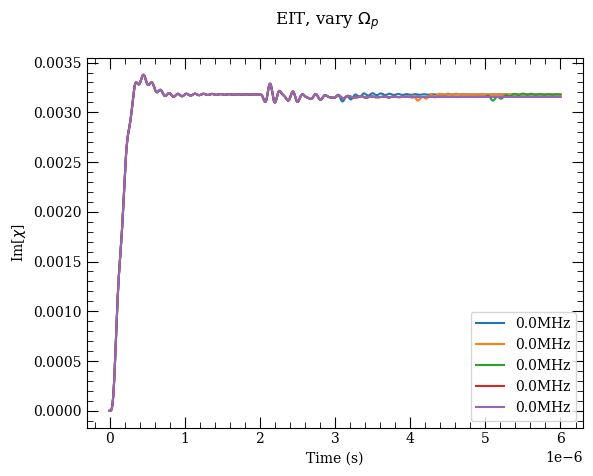

In [24]:
# Define time-dependent coefficient function
def hamiltonian_time_interval(t, args): 
    A = args['A']   
    t_start = args['start']  
    t_stop = args['stop'] 
    if t < t_start:
        return 0 
    elif t_start <= t < t_stop: 
        return A
    else: 
        return 0

psi0=basis(4,0) 

#print(tlist)
L=7.5e-2 # Cell length

pressure = pressure_Rb85(temperature)
N_0 = atomdensity(pressure, temperature)

rabi12 = 0.1e6 
rabi23 = 40e6 
rabi34 = 0 
rabi34_value = 20e6 
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-50.e6, 50.e6, 101) 
t_array = np.linspace(1,5,5)*1e-6 
# for rabi23 in Rabi23:
# for rabi34 in Rabi34:
Rabifreq = [rabi12,rabi23,rabi34]
    #print(Rabifreq)

fig, ax = plt.subplots()
res_split_time = []
    #for delta12 in dp:  
for interval in t_array: 
    res_split = [] 
    for delta23 in dc:    
        delta = [delta12,delta23,delta34]
        H0 = 1/2*Qobj(Hdiag(delta) + Hoff(Rabifreq))  
        H1 = 1/2*(rho[2][3].dag() + rho[2][3])
        H = [H0,[H1,hamiltonian_time_interval]] 
    #    print(H)
        
    # result = steadystate(H, c_op_list)
        result = mesolve(H, psi0, tlist, c_op_list,rho[0][1].dag(),args={'A': rabi34_value ,'start' : t_start,'stop' : t_start + interval})
        print(t_start + interval)
        res_split.append(result.expect)
    # print(H)   
    # print(c_op_list)
    # print(rabi34)
    #    print(res_split[0][0])
    # print(np.imag(res))
        Efield = E_from_Rabi(rabi12,abs(dipmat12)) 
    res_split_time.append(res_split)
    # print()
    #chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res[0]]
    # # print(np.imag(chi))
    # transmittance = [transmission(L,np.imag(i),lambda12) for i in chi]
    # refraction = np.real(chi)
    # absorption = 2*pi*np.imag(chi)/lambda12
    # print(np.imag(chi)[0])
    # # print(absorption)
    
    # # ax.plot(dp,refraction, label=rabi23*1e-6)
    ax.plot(tlist,res_split[2][0], label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][1]
    # ax.plot(tlist,np.real(res[0][0]), label=str(round(rabi12*1e-6,0))+'MHz') # for rho[0][0]
    #print(res)

# ax.plot(times, result.expect[1]) 
ax.set_xlabel('Time (s)') 
ax.set_ylabel('Im[$\chi$]') 
# ax.legend(("Sigma-Z", "Sigma-Y"))  
ax.legend()
# plt.suptitle('EIT, vary $\Omega_{RF}$')
plt.suptitle('EIT, vary $\Omega_{p}$')
# plt.ylim(-0.0007,-0.0006) 
plt.show()

In [25]:
Efield = E_from_Rabi(rabi12,abs(dipmat12)) 
chi_list = []
for i in range(len(dc)):  
    chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res_split[i][0]] 
    chi_list.append(chi)
    plt.plot(np.imag(chi))

In [26]:
Efield = E_from_Rabi(rabi12,abs(dipmat12))  
chi_list_time = []
for time in range(len(t_array)):  
    chi_list = [] 
    print(t_array[time])
    for i in range(len(dc)):   
        res_split = res_split_time[time] 
        chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res_split[i][0]] 
        chi_list.append(chi)
    chi_list_time.append(chi_list)

1e-06
2e-06
3e-06
4e-06
4.9999999999999996e-06


<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\3551125643.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(tlist, -1 * np.imag(chi_list_time[i][50]), label=f"{t:.1f} ($\mu$s)")


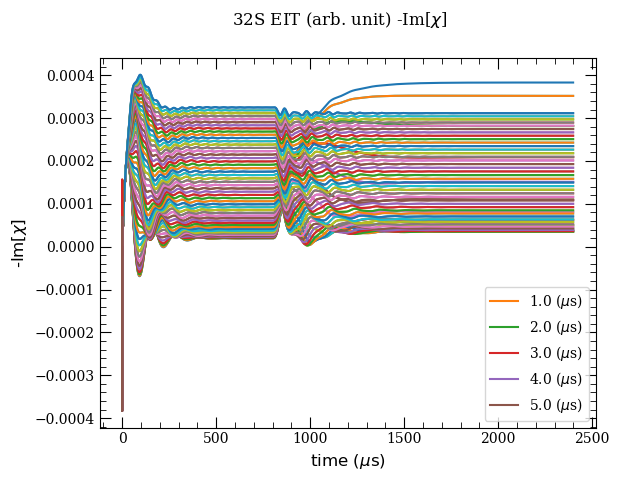

In [27]:
font1 = {'family': 'serif', 'fontsize': 14}  # Use fontsize
font2 = {'family': 'sans-serif', 'fontsize': 12}

frame_time = []
for i in range(len(t_array)):   
    t = t_array[i] * 1e6
    plt.plot(tlist, -1 * np.imag(chi_list_time[i][50]), label=f"{t:.1f} ($\mu$s)")  
    frame_time.append(-1 * np.imag(chi_list_time[i][50])) 

# Set titles and labels
plt.suptitle('32S EIT (arb. unit) ' + r'-Im[$\chi$]', fontdict=font1) 
plt.xlabel("time" + r" ($\mu$s)", fontdict=font2) 
plt.ylabel(r"-Im[$\chi$]", fontdict=font2)
plt.legend()  
plt.show()


# change rabi12

In [201]:
t_array = np.array([0.1,0.2,0.5,1,2])*1e-6 
rabi12 = 5.0e6 
rabi23 = 40e6 
rabi34 = 0 
rabi34_value = 20e6  
omegaC_list = np.array([5,10,25,50,100])*1e6
dp = np.linspace(-100.e6, 100.e6, 201)
dc = np.linspace(-50.e6, 50.e6, 201)  
dc_on_off = np.array([0,rabi34_value/2])
#t_array = np.linspace(1,5,5)*1e-6 
# for rabi23 in Rabi23:
# for rabi34 in Rabi34:
Rabifreq = [rabi12,rabi23,rabi34]
    #print(Rabifreq) 
res_split_compare_time = []
for interval in t_array:
    res_split_compare = []
    for rabi23 in omegaC_list: 
        res_split = [] 
        for delta23 in dc_on_off:    
            delta = [delta12,delta23,delta34]  
            Rabifreq = [rabi12,rabi23,rabi34]
            H0 = 1/2*Qobj(Hdiag(delta) + Hoff(Rabifreq))  
            H1 = 1/2*(rho[2][3].dag() + rho[2][3])
            H = [H0,[H1,hamiltonian_time_interval]] 
        #    print(H)
            
        # result = steadystate(H, c_op_list)
            result = mesolve(H, psi0, tlist, c_op_list,rho[0][1].dag(),args={'A': rabi34_value ,'start' : t_start,'stop' : t_start + interval})
            #print(t_start + interval)
            res_split.append(result.expect)
        # print(H)   
        # print(c_op_list)
        # print(rabi34)
        #    print(res_split[0][0])
        # print(np.imag(res))
            Efield = E_from_Rabi(rabi12,abs(dipmat12)) 
        res_split_compare.append(res_split) 
    res_split_compare_time.append(res_split_compare)

ax.set_xlabel('Time (s)') 
ax.set_ylabel('Im[$\chi$]') 
# ax.legend(("Sigma-Z", "Sigma-Y"))  
ax.legend()
# plt.suptitle('EIT, vary $\Omega_{RF}$')
plt.suptitle('EIT, vary $\Omega_{p}$')
# plt.ylim(-0.0007,-0.0006) 
plt.show()

<>:42: SyntaxWarning: invalid escape sequence '\c'
<>:46: SyntaxWarning: invalid escape sequence '\O'
<>:42: SyntaxWarning: invalid escape sequence '\c'
<>:46: SyntaxWarning: invalid escape sequence '\O'
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\1019408262.py:42: SyntaxWarning: invalid escape sequence '\c'
  ax.set_ylabel('Im[$\chi$]')
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\1019408262.py:46: SyntaxWarning: invalid escape sequence '\O'
  plt.suptitle('EIT, vary $\Omega_{p}$')


<Figure size 640x480 with 0 Axes>

In [202]:
len(res_split_compare_time[4][4]) 

2

In [203]:
Efield = E_from_Rabi(rabi12,abs(dipmat12))   
chi_list_compare_time = []
for interval in range(len(t_array)):  
    chi_list = [] 
    for i in range(len(dc_on_off)):   
        res_split = res_split_compare_time[interval][1] 
        chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res_split[i][0]] 
        chi_list.append(chi)
    chi_list_compare_time.append(chi_list)

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\c'
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\4227247996.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(tlist,-1*np.imag(chi_list_compare_time[i][0]),label =str("%.1f"%t) +  "$ \mu$s")
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\4227247996.py:8: SyntaxWarning: invalid escape sequence '\c'
  plt.suptitle('32S EIT (arb. unit) '+"-Im[$\chi$]", fontdict = font1)
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\4227247996.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("time"+"($\mu$s)", fontdict = font2)
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\42

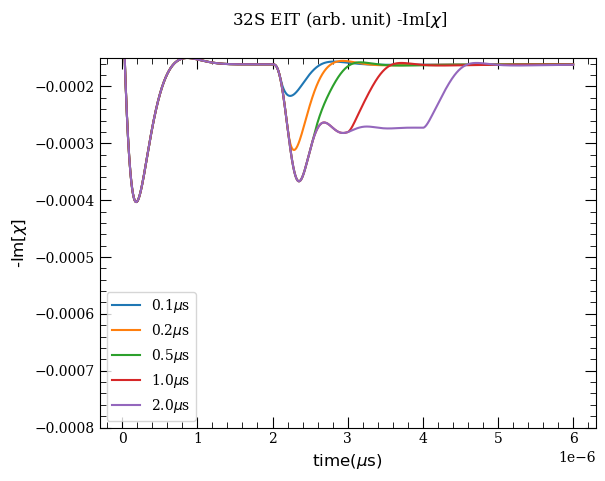

In [204]:
im_chi_on_resonance_time = []
for i in range(len(t_array)):    
    t = t_array[i]*1e6
    im_chi_on_resonance_time.append(-1*np.imag(chi_list_compare_time[i][0]))
    plt.plot(tlist,-1*np.imag(chi_list_compare_time[i][0]),label =str("%.1f"%t) +  "$ \mu$s")  

# activation time 2e-6
plt.suptitle('32S EIT (arb. unit) '+"-Im[$\chi$]", fontdict = font1) 
plt.xlabel("time"+"($\mu$s)", fontdict = font2) 
plt.ylabel("-Im[$\chi$]", fontdict = font2)  
plt.ylim(-0.00080,-0.00015)
plt.legend()  
plt.show() 

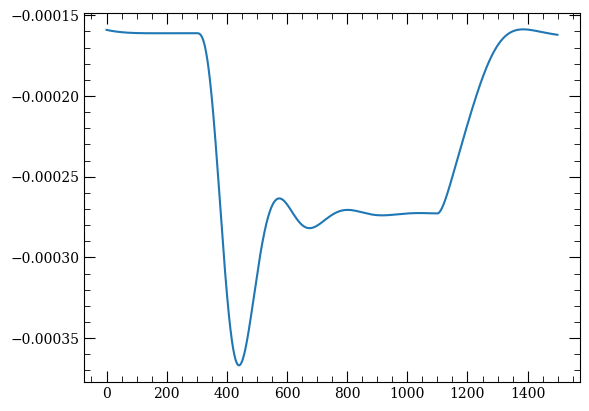

In [205]:
# This one ,we use it for plot the small curve inside the graph that compare in each different omegaC and time durations
data_curve = -1*np.imag(chi_list_compare_time[4][0])[500:2000]
plt.plot(data_curve)
plt.show()

In [206]:
data_chi_on_resonance = [] 
Efield = E_from_Rabi(rabi12,abs(dipmat12))   
for rabi in range(len(omegaC_list)):    
    chi_list_compare_time = []
    for interval in range(len(t_array)):  
        chi_list = [] 
        for i in range(len(dc_on_off)):   
            res_split = res_split_compare_time[interval][rabi] 
            chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res_split[i][0]] 
            chi_list.append(chi) 
        chi_list_compare_time.append(chi_list[0])  
    data_chi_on_resonance.append(chi_list_compare_time)

In [207]:
def classify_rectangle(data_sim_time_array,num_file,start_crop,end_crop):  
    if end_crop > len(tlist): 
        end_crop = len(tlist)
    time_duration = tlist[start_crop:end_crop]
    data_pulse = data_sim_time_array[int(num_file)][start_crop:end_crop] 
    x_data = time_duration*1e6
    y_data = data_pulse*1e4 

    horizontal_line = np.nanmean(y_data)   
    base_line = np.nanmean(y_data[-300:-1]) 
    plt.axhline(base_line,color='yellow', linestyle='--', linewidth=3,label = "Max line")  
    plt.plot(x_data,y_data) 
    plt.axhline(horizontal_line,color='black', linestyle='--', linewidth=3,label = "Max line") 
    idx = np.argwhere(np.diff(np.sign(y_data - horizontal_line))).flatten()  
    idx = np.delete(idx,np.where(idx < 350)) 
    print(idx)
    plt.plot(x_data[idx], y_data[idx], 'ro') 

    if (idx[1]-idx[0]) < 400 :  
        peaks = np.argmax(y_data)
        print(peaks,base_line)
        half_max = (y_data[peaks] + base_line)*0.5 
        idx_half = np.argwhere(np.diff(np.sign(y_data - half_max))).flatten()  
        print(idx_half)   
        if len(idx_half) > 2 :  
            closet_idx = np.delete(idx_half,np.where(idx_half < int(peaks/3)))
        else : 
            closet_idx = idx_half 
        print("closet_index  to peak = ",closet_idx)
        #sorted_idx = sorted(idx_half, key=lambda x: abs(x - peaks))  
        #closet_idx = sorted_idx[:2]
        plt.plot(x_data[closet_idx][:2], y_data[closet_idx][:2], 'yo',label = "Intersection points")  
        print('half_max = ',half_max)   
        fwm_rectan = x_data[closet_idx][1] - x_data[closet_idx][0]
        print('FWM = ',fwm_rectan)
    else: 
        # Initialize the RectangleModel and ConstantModel
        rect_model = RectangleModel()
        const_model = ConstantModel()

        # Combine the models
        model = rect_model + const_model

        # Guess the initial parameters
        params = model.make_params()
        params.update(rect_model.guess(y_data, x=x_data))
        params.update(const_model.guess(y_data, x=x_data))

        # Print the guessed parameters
        print("Guessed Parameters:")
        for name, param in params.items():
            print(f"{name}: {param.value}")
        # Set constraints on the parameters 
        # previous value 
        params['amplitude'].max = 2.25  and 4.25
        # params['amplitude'].max = 4.10
        # Fit the model to the noisy data
        result = model.fit(y_data, params, x=x_data) 
        # Print the fit report
        print(result.fit_report()) 
        fwm_rectan =  result.params['center2'].value - result.params['center1'].value 
        plt.plot(x_data, result.best_fit, color='red', label='Best Fit')
        plt.xlabel('X')
        plt.ylabel('Y')
        plt.title('classify rectangle')
        plt.legend()  
        
        if result.rsquared < 0.922 :
            peaks = np.argmax(y_data)
            half_max = (y_data[peaks] + base_line)*0.5 
            idx_half = np.argwhere(np.diff(np.sign(y_data - half_max))).flatten()  
            print(idx_half)   
            if len(idx_half) > 2 :  
                closet_idx = np.delete(idx_half,np.where(idx_half < int(peaks/3)))
            else : 
                closet_idx = idx_half 
            print("closet_index  to peak = ",closet_idx)
            #sorted_idx = sorted(idx_half, key=lambda x: abs(x - peaks))  
            #closet_idx = sorted_idx[:2]
            plt.plot(x_data[closet_idx][:2], y_data[closet_idx][:2], 'yo',label = "Intersection points")  
            print('half_max = ',half_max)   
            fwm_rectan = x_data[closet_idx][1] - x_data[closet_idx][0]
            print('FWM = ',fwm_rectan) 
        else: 
            fwm_rectan = fwm_rectan
    plt.axvline(x_data[300],color='black', linestyle='--', linewidth=3,label = "Max line")  
    plt.axvline(x_data[1100],color='black', linestyle='--', linewidth=3,label = "Max line") 
    plt.show()   
    return fwm_rectan

[477 802]
550 2.6079621363625574
[ 21 493 675]
closet_index  to peak =  [493 675]
half_max =  2.680865272652683
FWM =  0.45518966235931657


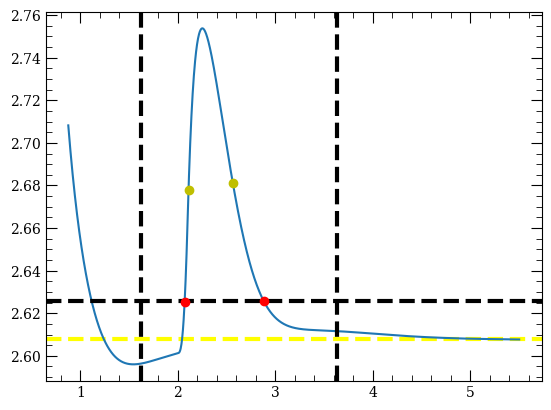

rabiC = 5.0 MHz, im chi = 0
[488 889]
Guessed Parameters:
amplitude: 0.4215630931554166
center1: 1.5937890787828264
sigma1: 0.6606324063597928
center2: 4.781367236348479
sigma2: 0.6606324063597928
c: 2.659270956889543
midpoint: 3.1875781575656528
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 249
    # data points      = 1850
    # variables        = 6
    chi-square         = 0.67845166
    reduced chi-square = 3.6792e-04
    Akaike info crit   = -14623.1335
    Bayesian info crit = -14589.9958
    R-squared          = 0.96307414
[[Variables]]
    amplitude:  0.48716051 +/- 47168181.6 (9682267112.24%) (init = 0.4215631)
    center1:    2.16701138 +/- 8295227.11 (382795733.98%) (init = 1.593789)
    sigma1:     0.08567479 +/- 8291792.54 (9678217806.78%) (init = 0.6606324)
    center2:    2.56973961 +/- 47210844.0 (1837183961.89%) (init = 4.781367)
    sigma2:     0.48760312 +/- 47199998.0 (9

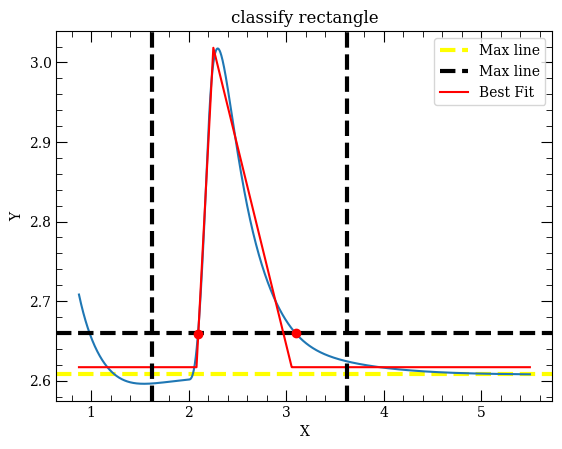

rabiC = 5.0 MHz, im chi = 1
[495 969]
Guessed Parameters:
amplitude: 0.5849747412462682
center1: 1.5937890787828264
sigma1: 0.6606324063597928
center2: 4.781367236348479
sigma2: 0.6606324063597928
c: 2.6910297644047536
midpoint: 3.1875781575656528
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 132
    # data points      = 1850
    # variables        = 6
    chi-square         = 1.16914065
    reduced chi-square = 6.3402e-04
    Akaike info crit   = -13616.3431
    Bayesian info crit = -13583.2054
    R-squared          = 0.96969637
[[Variables]]
    amplitude:  0.61549304 +/- 65610131.2 (10659768236.58%) (init = 0.5849747)
    center1:    2.18846704 +/- 11057447.9 (505259968.78%) (init = 1.593789)
    sigma1:     0.10373033 +/- 11059506.5 (10661787129.30%) (init = 0.6606324)
    center2:    2.74775388 +/- 70634957.6 (2570643534.00%) (init = 4.781367)
    sigma2:     0.66262940 +/- 70643419.6

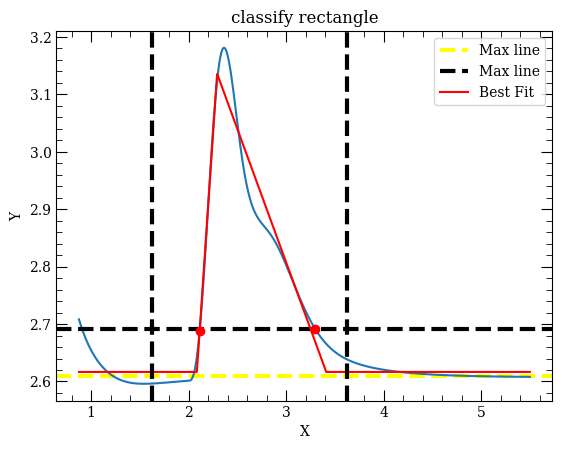

rabiC = 5.0 MHz, im chi = 2
[ 505 1124]
Guessed Parameters:
amplitude: 0.5849747412462682
center1: 1.5937890787828264
sigma1: 0.6606324063597928
center2: 4.781367236348479
sigma2: 0.6606324063597928
c: 2.7430667377747886
midpoint: 3.1875781575656528
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 172
    # data points      = 1850
    # variables        = 6
    chi-square         = 4.00067932
    reduced chi-square = 0.00216957
    Akaike info crit   = -11340.4820
    Bayesian info crit = -11307.3443
    R-squared          = 0.93271987
[[Variables]]
    amplitude:  0.60266142 +/- 79923170.7 (13261703551.69%) (init = 0.5849747)
    center1:    2.19228994 +/- 14541231.8 (663289632.34%) (init = 1.593789)
    sigma1:     0.10964846 +/- 14539710.5 (13260295614.75%) (init = 0.6606324)
    center2:    3.18068404 +/- 1.4566e+08 (4579439726.42%) (init = 4.781367)
    sigma2:     1.09833354 +/- 1.4565e+

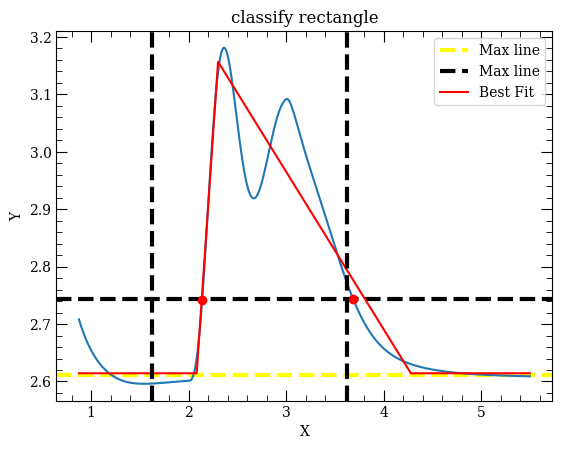

rabiC = 5.0 MHz, im chi = 3
[ 521 1440]
Guessed Parameters:
amplitude: 0.5849747412462682
center1: 1.5937890787828264
sigma1: 0.6606324063597928
center2: 4.781367236348479
sigma2: 0.6606324063597928
c: 2.8447926091981226
midpoint: 3.1875781575656528
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 78
    # data points      = 1850
    # variables        = 6
    chi-square         = 3.07900007
    reduced chi-square = 0.00166974
    Akaike info crit   = -11824.9216
    Bayesian info crit = -11791.7840
    R-squared          = 0.96193722
[[Variables]]
    amplitude:  0.44703250 +/- 0.00217572 (0.49%) (init = 0.5849747)
    center1:    2.17529366 +/- 0.00196312 (0.09%) (init = 1.593789)
    sigma1:     0.08828333 +/- 0.00332694 (3.77%) (init = 0.6606324)
    center2:    4.50275011 +/- 0.00492444 (0.11%) (init = 4.781367)
    sigma2:     0.46019102 +/- 0.00791955 (1.72%) (init = 0.6606324)
    c:  

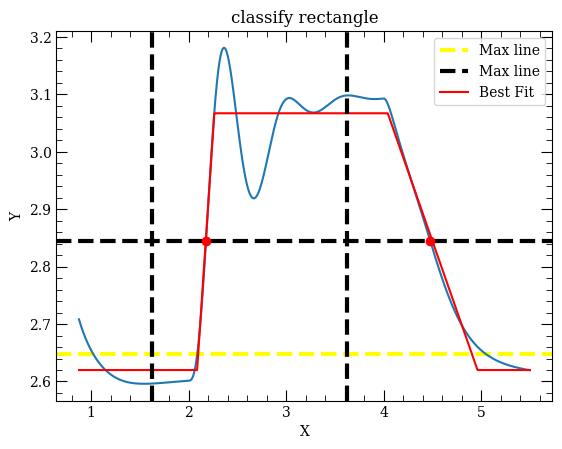

rabiC = 5.0 MHz, im chi = 4
[469 692]
544 1.614149239385172
[493 623]
closet_index  to peak =  [493 623]
half_max =  1.8905384221672077
FWM =  0.3251354731137974


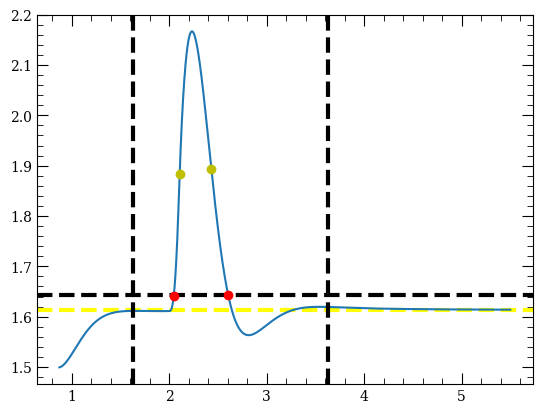

rabiC = 10.0 MHz, im chi = 0
[479 728]
564 1.6148478332614487
[515 645]
closet_index  to peak =  [515 645]
half_max =  2.3663254557267916
FWM =  0.3251354731137974


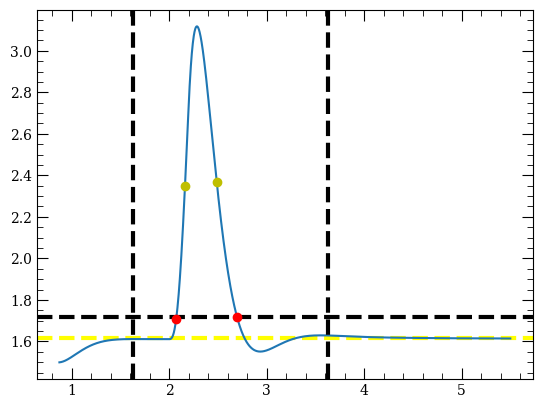

rabiC = 10.0 MHz, im chi = 1
[487 806]
590 1.6155257977326931
[526 688]
closet_index  to peak =  [526 688]
half_max =  2.6420908877488722
FWM =  0.4051688203418089


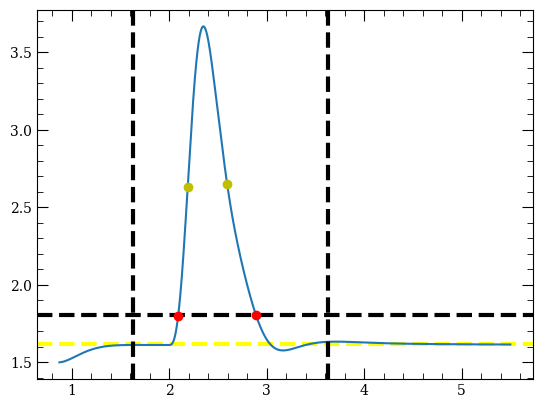

rabiC = 10.0 MHz, im chi = 2
[495 993]
Guessed Parameters:
amplitude: 2.169358218492027
center1: 1.5937890787828264
sigma1: 0.6606324063597928
center2: 4.781367236348479
sigma2: 0.6606324063597928
c: 1.9303674827924204
midpoint: 3.1875781575656528
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 159
    # data points      = 1850
    # variables        = 6
    chi-square         = 20.4499853
    reduced chi-square = 0.01109001
    Akaike info crit   = -8322.17370
    Bayesian info crit = -8289.03605
    R-squared          = 0.96523899
[[Variables]]
    amplitude:  2.20887591 +/- 5.5907e+08 (25310241838.41%) (init = 2.169358)
    center1:    2.18204625 +/- 26510588.7 (1214941647.22%) (init = 1.593789)
    sigma1:     0.10474174 +/- 26511894.8 (25311681357.85%) (init = 0.6606324)
    center2:    2.85774271 +/- 1.9783e+08 (6922678837.75%) (init = 4.781367)
    sigma2:     0.78162377 +/- 1.9784e+08

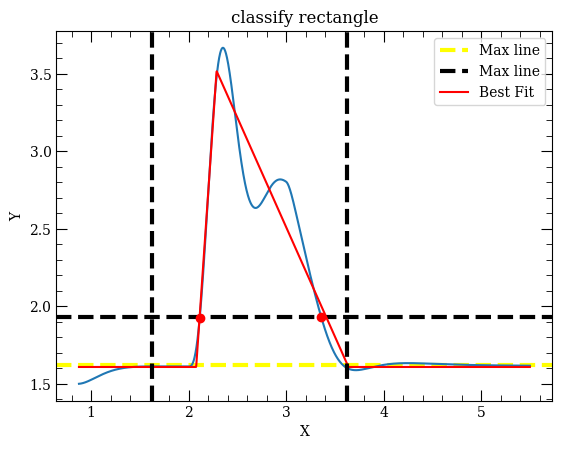

rabiC = 10.0 MHz, im chi = 3
[ 507 1351]
Guessed Parameters:
amplitude: 2.169358218492027
center1: 1.5937890787828264
sigma1: 0.6606324063597928
center2: 4.781367236348479
sigma2: 0.6606324063597928
c: 2.168025253704334
midpoint: 3.1875781575656528
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 86
    # data points      = 1850
    # variables        = 6
    chi-square         = 53.2951497
    reduced chi-square = 0.02890193
    Akaike info crit   = -6550.12684
    Bayesian info crit = -6516.98920
    R-squared          = 0.92357736
[[Variables]]
    amplitude:  1.25376980 +/- 0.00866996 (0.69%) (init = 2.169358)
    center1:    2.14587219 +/- 0.00262326 (0.12%) (init = 1.593789)
    sigma1:     0.07291961 +/- 0.00443616 (6.08%) (init = 0.6606324)
    center2:    4.23296464 +/- 0.00553439 (0.13%) (init = 4.781367)
    sigma2:     0.28975789 +/- 0.00914668 (3.16%) (init = 0.6606324)
    c:    

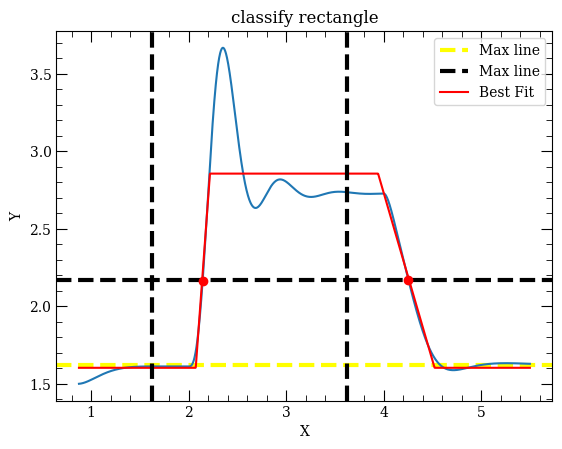

rabiC = 10.0 MHz, im chi = 4
[462 574 685 765]
516 0.4401200909807085
[488 551]
closet_index  to peak =  [488 551]
half_max =  0.8715994582108739
FWM =  0.15756565235514808


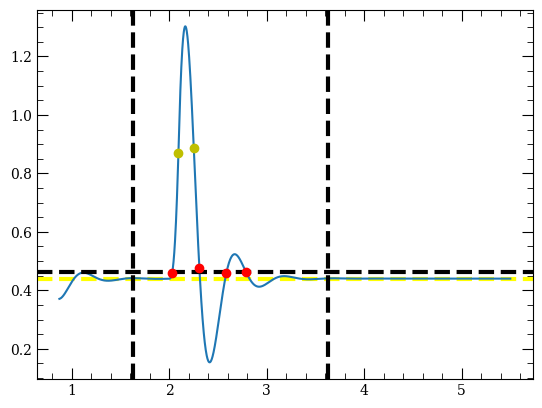

rabiC = 25.0 MHz, im chi = 0
[469 602 713 790]
542 0.4402321671551338
[507 578]
closet_index  to peak =  [507 578]
half_max =  1.5734494575971345
FWM =  0.17757398916215061


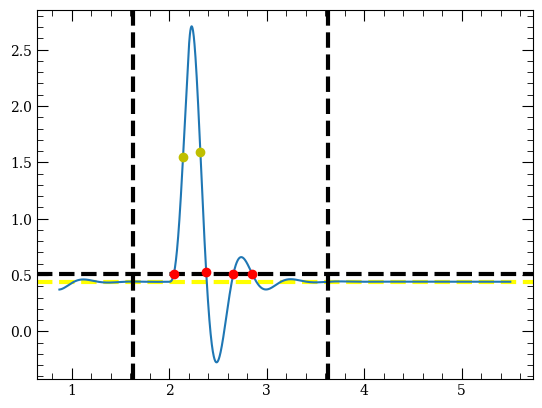

rabiC = 25.0 MHz, im chi = 1
[479 706 842 865]
576 0.4407311647764263
[515 682]
closet_index  to peak =  [515 682]
half_max =  1.8919882494786644
FWM =  0.41767403084618593


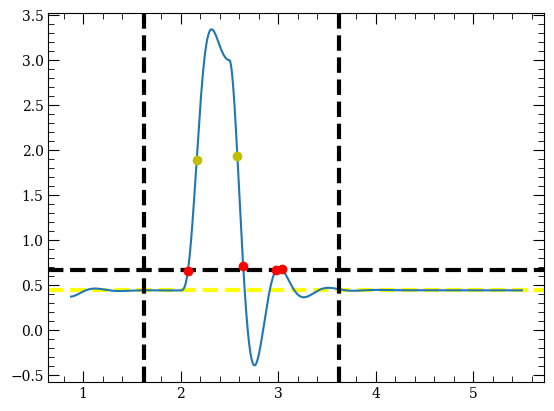

rabiC = 25.0 MHz, im chi = 2
[489 897]
Guessed Parameters:
amplitude: 3.5612538720009335
center1: 1.5937890787828264
sigma1: 0.6606324063597928
center2: 4.781367236348479
sigma2: 0.6606324063597928
c: 0.9175724232841004
midpoint: 3.1875781575656528
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 337
    # data points      = 1850
    # variables        = 6
    chi-square         = 112.832737
    reduced chi-square = 0.06118912
    Akaike info crit   = -5162.51365
    Bayesian info crit = -5129.37600
    R-squared          = 0.93551845
[[Variables]]
    amplitude:  4.24984056 +/- 0.07534667 (1.77%) (init = 3.561254)
    center1:    2.27934530 +/- 0.00384094 (0.17%) (init = 1.593789)
    sigma1:     0.31338462 +/- 0.00514162 (1.64%) (init = 0.6606324)
    center2:    2.79750553 +/- 0.00725531 (0.26%) (init = 4.781367)
    sigma2:     0.46384638 +/- 0.00759201 (1.64%) (init = 0.6606324)
    c:   

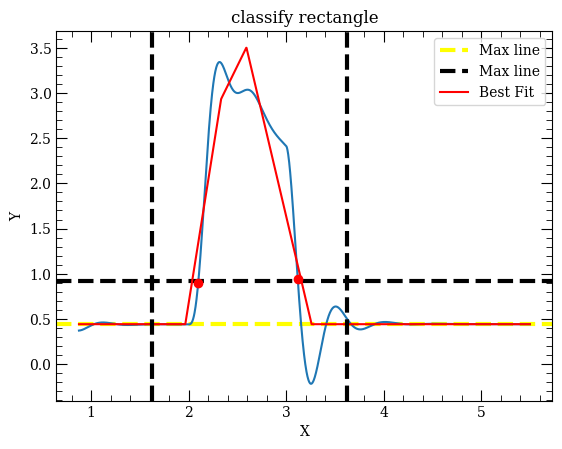

rabiC = 25.0 MHz, im chi = 3
[ 500 1284]
Guessed Parameters:
amplitude: 3.4355671788921542
center1: 1.5937890787828264
sigma1: 0.6606324063597928
center2: 4.781367236348479
sigma2: 0.6606324063597928
c: 1.2735159294353928
midpoint: 3.1875781575656528
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 71
    # data points      = 1850
    # variables        = 6
    chi-square         = 130.271132
    reduced chi-square = 0.07064595
    Akaike info crit   = -4896.64756
    Bayesian info crit = -4863.50992
    R-squared          = 0.93346638
[[Variables]]
    amplitude:  2.68937559 +/- 0.02387944 (0.89%) (init = 3.435567)
    center1:    2.15638581 +/- 0.00225941 (0.10%) (init = 1.593789)
    sigma1:     0.09117581 +/- 0.00373804 (4.10%) (init = 0.6606324)
    center2:    3.58631731 +/- 0.01108900 (0.31%) (init = 4.781367)
    sigma2:     0.97684161 +/- 0.01478164 (1.51%) (init = 0.6606324)
    c:  

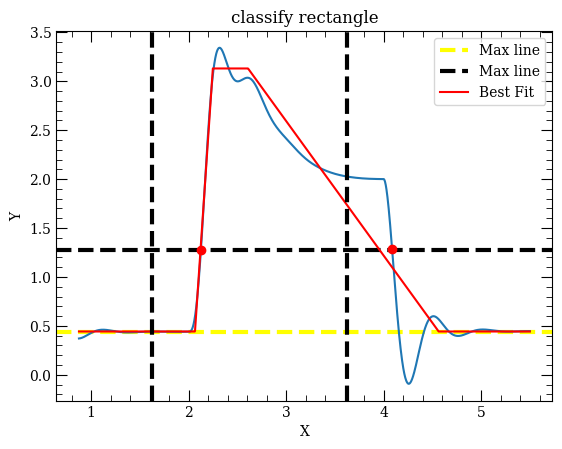

rabiC = 25.0 MHz, im chi = 4
[458 527 578 627 680 726 784 821]
499 0.12233588442606627
[482 517]
closet_index  to peak =  [482 517]
half_max =  0.4037137551856213
FWM =  0.08753647353063787


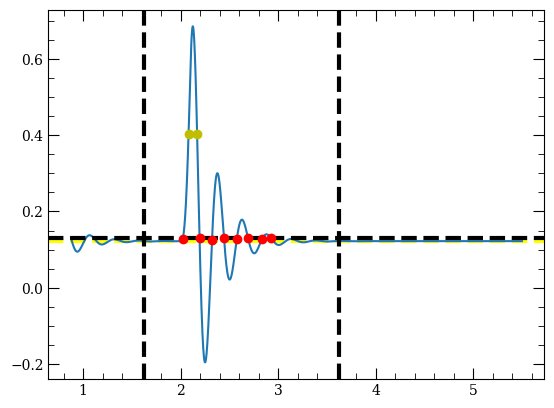

rabiC = 50.0 MHz, im chi = 0
[462 558 610 658 712 755 821 846]
531 0.12234768294426088
[494 548]
closet_index  to peak =  [494 548]
half_max =  0.678749077989717
FWM =  0.13505627344726978


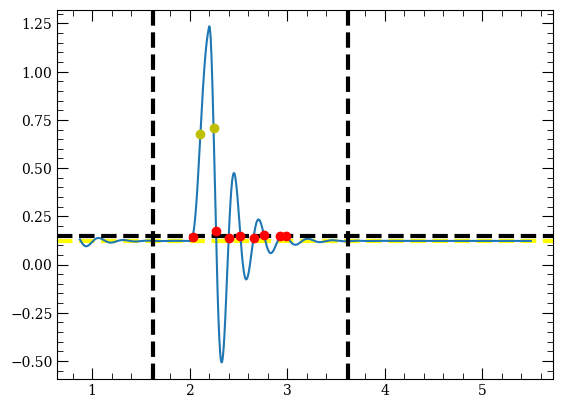

rabiC = 50.0 MHz, im chi = 1
[472 676 731 774 839 864]
650 0.12243749198500267
[508 667]
closet_index  to peak =  [508 667]
half_max =  0.9851638404316874
FWM =  0.3976656940391834


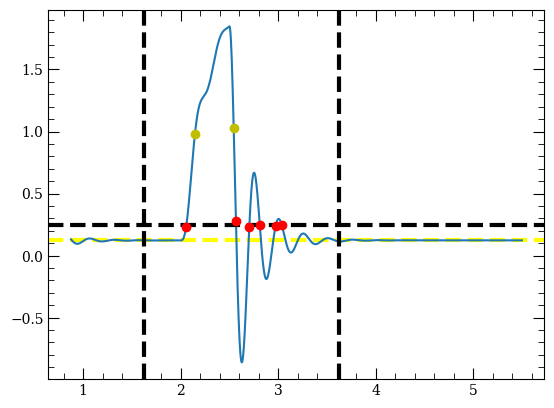

rabiC = 50.0 MHz, im chi = 2
[483 873 935 966]
784 0.12277851335626608
[513 866]
closet_index  to peak =  [513 866]
half_max =  1.0642863928412378
FWM =  0.8828678616090038


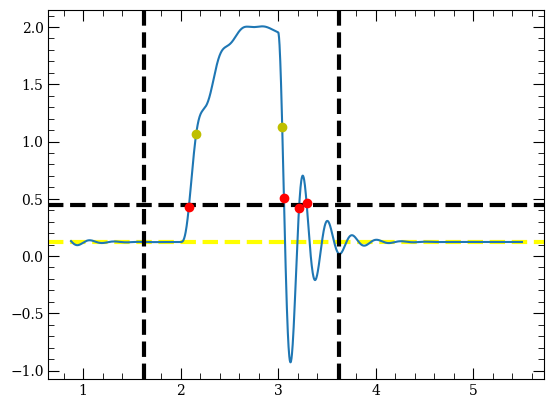

rabiC = 50.0 MHz, im chi = 3
[ 499 1267]
Guessed Parameters:
amplitude: 2.7232619938846767
center1: 1.5937890787828264
sigma1: 0.6606324063597928
center2: 4.781367236348479
sigma2: 0.6606324063597928
c: 0.7911365377584169
midpoint: 3.1875781575656528
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 141
    # data points      = 1850
    # variables        = 6
    chi-square         = 40.8367571
    reduced chi-square = 0.02214575
    Akaike info crit   = -7042.71292
    Bayesian info crit = -7009.57527
    R-squared          = 0.96742728
[[Variables]]
    amplitude:  1.71246570 +/- 0.00747796 (0.44%) (init = 2.723262)
    center1:    2.18232929 +/- 0.00281686 (0.13%) (init = 1.593789)
    sigma1:     0.19201121 +/- 0.00471928 (2.46%) (init = 0.6606324)
    center2:    4.03627779 +/- 0.00119938 (0.03%) (init = 4.781367)
    sigma2:     0.03804572 +/- 0.00202670 (5.33%) (init = 0.6606324)
    c: 

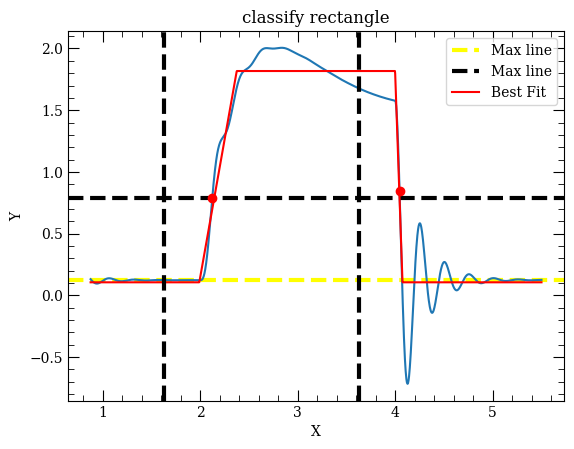

rabiC = 50.0 MHz, im chi = 4
[455 503 529 554 579 604 630 654 680 704 731 753 782 802 835 850]
491 0.03146379643259485
[473 499 537 544]
closet_index  to peak =  [473 499 537 544]
half_max =  0.13147386756065965
FWM =  0.06502709462275957


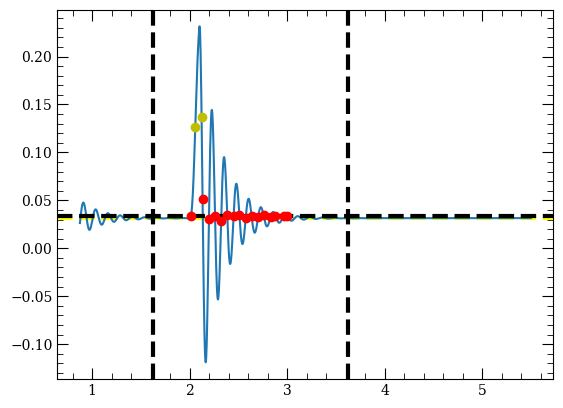

rabiC = 100.0 MHz, im chi = 0
[458 543 569 593 619 643 670 693 721 742 773 791 826 838]
531 0.031464738950152046
[482 539 577 584]
closet_index  to peak =  [482 539 577 584]
half_max =  0.19940273313474527
FWM =  0.14255939974989618


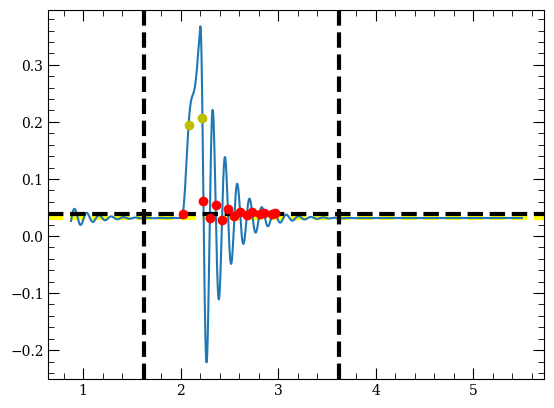

rabiC = 100.0 MHz, im chi = 1
[465 662 688 712 739 761 791 810 843 858]
650 0.031473079211712614
[525 658 696 703]
closet_index  to peak =  [525 658 696 703]
half_max =  0.3448542867690501
FWM =  0.3326385994164234


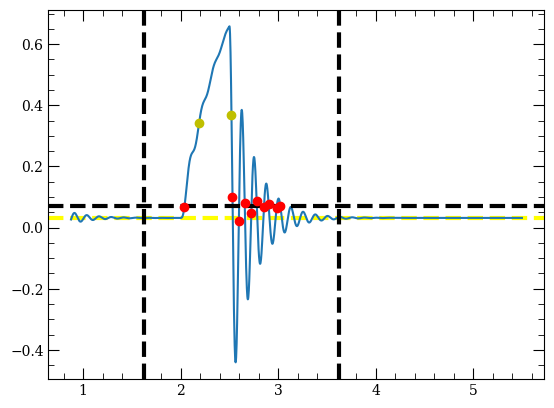

rabiC = 100.0 MHz, im chi = 2
[ 476  861  889  910  941  959  995 1005]
849 0.031511588048394955
[561 858 896 903]
closet_index  to peak =  [561 858 896 903]
half_max =  0.44657172473127055
FWM =  0.7428095039599829


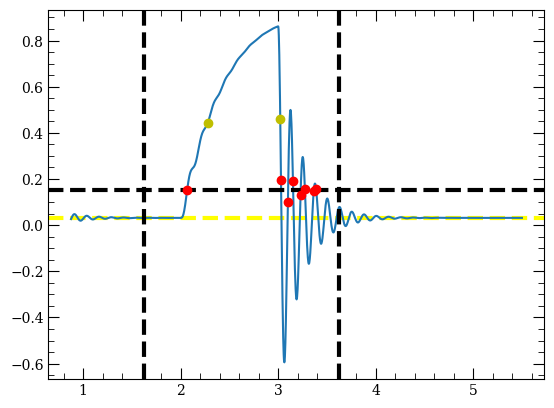

rabiC = 100.0 MHz, im chi = 3
[ 524 1259 1292 1306]
Guessed Parameters:
amplitude: 1.5079890702905723
center1: 1.5937890787828264
sigma1: 0.6606324063597928
center2: 4.781367236348479
sigma2: 0.6606324063597928
c: 0.3378706180520784
midpoint: 3.1875781575656528
[[Model]]
    (Model(rectangle, form='linear') + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 195
    # data points      = 1850
    # variables        = 6
    chi-square         = 26.2378141
    reduced chi-square = 0.01422875
    Akaike info crit   = -7861.11764
    Bayesian info crit = -7827.97999
    R-squared          = 0.90754173
[[Variables]]
    amplitude:  4.24999150 +/- 0.12799185 (3.01%) (init = 1.507989)
    center1:    2.93183566 +/- 0.00597699 (0.20%) (init = 1.593789)
    sigma1:     0.85075309 +/- 0.00399389 (0.47%) (init = 0.6606324)
    center2:    3.26311225 +/- 0.00654631 (0.20%) (init = 4.781367)
    sigma2:     0.92363271 +/- 0.00433407 (0.47%) (init = 0.66063

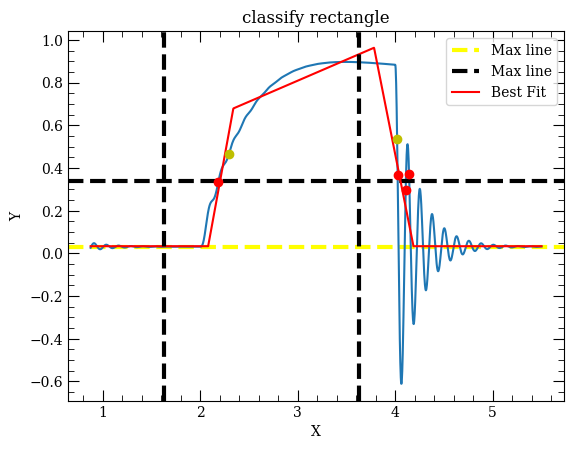

rabiC = 100.0 MHz, im chi = 4


In [208]:
data_cross_segment_width = [] 
for rabi in range(len(omegaC_list)):   
    im_chi_on_resonance_time = np.imag(data_chi_on_resonance[rabi]) 
    #print(omegaC_list[rabi]) 
    on_resonance_result = []
    for i in range(0,len(im_chi_on_resonance_time)):   
        #print(t_array[i]-t_array[0]) 
        dat = classify_rectangle(im_chi_on_resonance_time,i,350,2200)
        on_resonance_result.append(dat)   
        plt.show()  
        print(f"rabiC = {omegaC_list[rabi]/1e6} MHz, im chi = {i}")
    data_cross_segment_width.append(on_resonance_result) 
data_cross_segment_width = np.array(data_cross_segment_width)

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\c'
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\3188535848.py:12: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel("Pulse duration ($\mu$s)", fontdict=font2)
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\3188535848.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel("Measuring time ($\mu$s)", fontdict=font2)
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\3188535848.py:30: SyntaxWarning: invalid escape sequence '\c'
  small_plot.set_title("-Im[$\chi$]", fontsize=12)


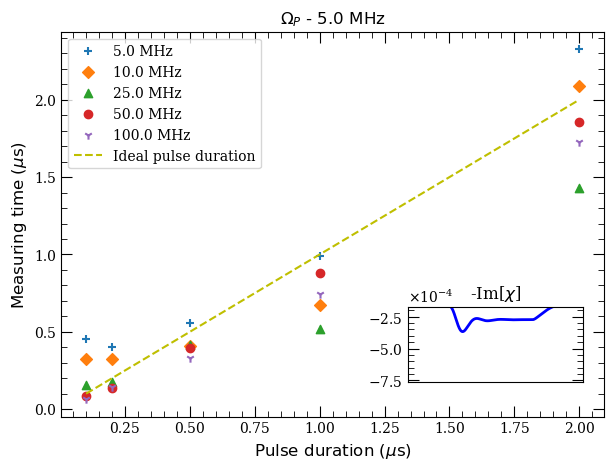

In [209]:
# Create figure and main plot
fig, ax = plt.subplots(figsize=(7, 5))

m = ['+', 'D', '^', 'o', '1']
for i in range(len(omegaC_list)): 
    ax.scatter(t_array * 1e6, data_cross_segment_width[i], marker=m[i], label=f"{omegaC_list[i]/1e6:.1f} MHz")  

# Dashed reference line
ax.plot(t_array * 1e6, t_array * 1e6, '--y', label='Ideal pulse duration')

# Labels and title
ax.set_xlabel("Pulse duration ($\mu$s)", fontdict=font2)
ax.set_ylabel("Measuring time ($\mu$s)", fontdict=font2)
ax.set_title(r"$\Omega_{P}$ - " + str(rabi12/1E6) + " MHz", fontdict=font2)
ax.legend()

# **Add Gaussian Inset (Region 1)**
small_plot = fig.add_axes([0.62, 0.18, 0.25, 0.15])  # [x, y, width, height]
#x_region1 = np.linspace(0, 500, 500)
y_region1 = data_curve
small_plot.plot(y_region1, color="blue", linewidth=2) 

# Format Y-axis to scientific notation (10^-4)
small_plot.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
small_plot.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))  # Force scientific notation
small_plot.yaxis.get_offset_text().set_fontsize(10)  # Adjust font size of exponent
small_plot.set_ylim(-0.00076, -0.00017)
small_plot.set_xticks([])
#left_inset.set_yticks([])
small_plot.set_title("-Im[$\chi$]", fontsize=12)

# Save and show the final figure
plt.savefig("measure_short_pulse_omegaP"+str(rabi12/1E6)+"(MHz).png", dpi=300, bbox_inches='tight')
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\O'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\O'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\1044595313.py:10: SyntaxWarning: invalid escape sequence '\O'
  plt.suptitle(" Residual plot -$\Omega_{P}$ - "+str(rabi12/1E6)+" (MHz) ", fontdict = font2)
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\1044595313.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Pulse duration "+"($\mu$s)", fontdict = font2)
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\1044595313.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Deviation measuring time"+"($\mu$s)", fontdict = font2)


[ 0.49024594  0.27552625  0.03953299 -0.10193544  0.20838265]
[ 0.27765736  0.1801584  -0.0423093   0.0708172   0.06398901]
[ 0.06506878 -0.01742393 -0.07732388 -0.08905996 -0.10033064]
[-0.01246353 -0.06494373 -0.11734056 -0.23468112 -0.28554427]
[-0.03497291 -0.0574406  -0.17236348 -0.28470196 -0.36181742]


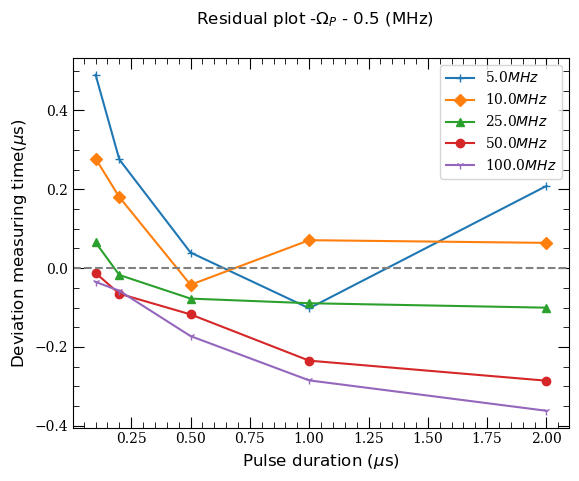

In [185]:
m=['+','D','^','o','1']
for i in range(len(omegaC_list)):  
    residual = data_cross_segment_width[i] - t_array*1e6
    plt.plot(t_array*1e6,data_cross_segment_width[i] - t_array*1e6,marker=m[i],label =str("%.1f"%(omegaC_list[i]/1e6)) +  "$  MHz$")   
    print(residual)
#plt.plot(t_array*1e6,t_array*1e6,'--y^',label= 'Pulse duration ')   
# Add a horizontal line at y = 0.0
plt.axhline(y=0.0, color="gray", linestyle="--", linewidth=1.5)
plt.legend()   
plt.suptitle(" Residual plot -$\Omega_{P}$ - "+str(rabi12/1E6)+" (MHz) ", fontdict = font2)
plt.xlabel("Pulse duration "+"($\mu$s)", fontdict = font2) 
plt.ylabel("Deviation measuring time"+"($\mu$s)", fontdict = font2) 
plt.savefig("measure_residual_pulse_omegaP"+str(rabi12/1E6)+"(MHz).png", dpi=300, bbox_inches='tight')  # Saves as PNG with high quality 
plt.show()

<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\O'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\1443974196.py:7: SyntaxWarning: invalid escape sequence '\O'
  plt.suptitle(" Residual plot -$\Omega_{P}$ - "+str(rabi12/1E6)+" (MHz) ", fontdict = font2)
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\1443974196.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Pulse duration "+"($\mu$s)", fontdict = font2)
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\1443974196.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel("Ratio of measuring time"+"($\mu$s)", fontdict = font2)


[4.90245936 1.37763123 0.07906598 0.10193544 0.10419132]


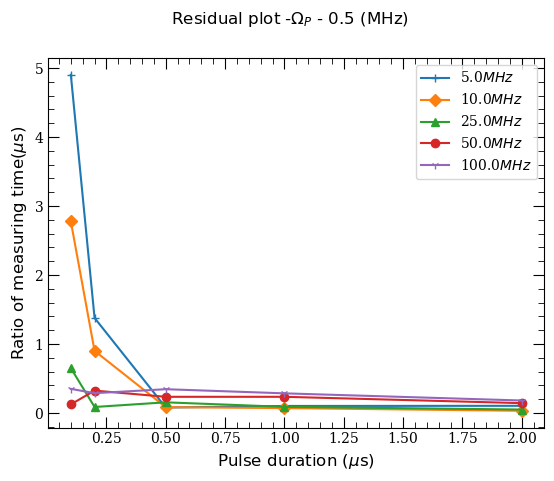

In [186]:
m=['+','D','^','o','1']
for i in range(len(omegaC_list)): 
    plt.plot(t_array*1e6,(abs(data_cross_segment_width[i] - t_array*1e6)/(t_array*1e6)),marker=m[i],label =str("%.1f"%(omegaC_list[i]/1e6)) +  "$  MHz$")  
#plt.plot(t_array*1e6,t_array*1e6,'--y^',label= 'Pulse duration ')  
print(abs(data_cross_segment_width[0] - t_array*1e6)/(t_array*1e6))
plt.legend()   
plt.suptitle(" Residual plot -$\Omega_{P}$ - "+str(rabi12/1E6)+" (MHz) ", fontdict = font2)
plt.xlabel("Pulse duration "+"($\mu$s)", fontdict = font2) 
plt.ylabel("Ratio of measuring time"+"($\mu$s)", fontdict = font2) 
plt.savefig("measure_ratio_pulse_omegaP"+str(rabi12/1E6)+"(MHz).png", dpi=300, bbox_inches='tight')  # Saves as PNG with high quality 
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\O'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\O'
<>:9: SyntaxWarning: invalid escape sequence '\m'
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\3608274808.py:8: SyntaxWarning: invalid escape sequence '\O'
  plt.suptitle("Inverse relative error plot -$\Omega_{P}$ - "+str(rabi12/1E6)+" (MHz) ", fontdict = font2)
C:\Users\beam_\AppData\Local\Temp\ipykernel_24240\3608274808.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel("Pulse duration "+"($\mu$s)", fontdict = font2)


[3.55189662 1.01364117 0.1185737  0.01160589 0.16372823]


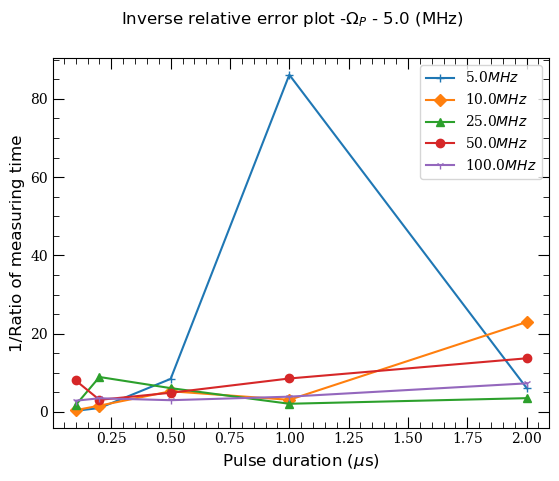

In [158]:
m=['+','D','^','o','1']
for i in range(len(omegaC_list)):  
    inverse_error = (t_array*1e6)/(abs(data_cross_segment_width[i] - t_array*1e6))
    plt.plot(t_array*1e6,inverse_error,marker=m[i],label =str("%.1f"%(omegaC_list[i]/1e6)) +  "$  MHz$")  
#plt.plot(t_array*1e6,t_array*1e6,'--y^',label= 'Pulse duration ')  
print(abs(data_cross_segment_width[0] - t_array*1e6)/(t_array*1e6))
plt.legend()   
plt.suptitle("Inverse relative error plot -$\Omega_{P}$ - "+str(rabi12/1E6)+" (MHz) ", fontdict = font2)
plt.xlabel("Pulse duration "+"($\mu$s)", fontdict = font2) 
plt.ylabel("1/Ratio of measuring time", fontdict = font2) 
plt.savefig("measure_inverse_ratio_pulse_omegaP"+str(rabi12/1E6)+"(MHz).png", dpi=300, bbox_inches='tight')  # Saves as PNG with high quality 
plt.show()

mutiple plot for residual

In [41]:
import pandas as pd

In [159]:

# Define the CSV file name
csv_filename = "measurement_data.csv"  

# Example new data (Replace with your real data)
test_rabi12 = 7.5e6  # Example label value
test_array = [0.2, 0.4, 0.6, 0.8, 1.0]  # Example pulse duration data (µs)
measuring_time = [0.22, 0.41, 0.63, 0.85, 1.05]  # Example measuring time data (µs)

# Convert to DataFrame
new_data = pd.DataFrame({f"Rabi_{test_rabi12/1e6:.1f}MHz": measuring_time}, index=test_array)
new_data.index.name = "Pulse Duration (µs)"  # Set index as Pulse Duration

# Check if CSV file exists
if os.path.exists(csv_filename):
    # Load existing data
    existing_data = pd.read_csv(csv_filename, index_col=0)

    # Update or add new column
    existing_data.update(new_data)  # Replace existing data
    for col in new_data.columns:
        if col not in existing_data.columns:
            existing_data[col] = new_data[col]  # Add new column if not exists
else:
    # If file doesn't exist, create new one
    existing_data = new_data

# Save to CSV
existing_data.to_csv(csv_filename)

print(f"Data saved to {csv_filename}") 

Data saved to measurement_data.csv


In [160]:
def update_csv(csv_filename, new_data):
    """
    Updates or creates a CSV file with properly formatted column labels, ensuring no data is duplicated.
    
    - If the file exists, it merges new data while keeping all pulse duration values.
    - If the file does not exist, it creates a new one.

    Parameters:
    - csv_filename (str): Name of the CSV file.
    - new_data (pd.DataFrame): DataFrame containing new data.
    
    Returns:
    - None (Saves the updated CSV file)
    """
    
    # Fix column labels: Add underscores for clarity
    new_data.columns = [col.replace("MHz", "MHz_").replace("OmegaP", "OmegaP_").replace("OmegaC", "OmegaC_") for col in new_data.columns]

    # Check if CSV file exists
    if os.path.exists(csv_filename):
        # Load existing data
        existing_data = pd.read_csv(csv_filename, index_col=0)

        # Merge new data properly (aligning by index)
        merged_data = existing_data.combine_first(new_data)  # Keeps all existing & new values
        
        # Ensure all new columns are included
        for col in new_data.columns:
            if col not in merged_data.columns:
                merged_data[col] = new_data[col]
    else:
        # If file doesn't exist, use the new data
        merged_data = new_data

    # Sort data to avoid index mismatches
    merged_data = merged_data.sort_index()

    # Save to CSV with index
    merged_data.to_csv(csv_filename, index=True)

    print(f"✅ Data successfully saved to {csv_filename}")

In [44]:
def update_csv_old(csv_filename, new_data):
    """
    Updates or creates a CSV file with new data.
    
    - If the file exists, it updates the existing column with the same label.
    - If the label doesn't exist, it adds a new column.
    - If the file does not exist, it creates a new one.

    Parameters:
    - csv_filename (str): Name of the CSV file.
    - new_data (pd.DataFrame): DataFrame containing new data.
    
    Returns:
    - None (Saves the updated CSV file)
    """
    
    # Check if the CSV file exists
    if os.path.exists(csv_filename):
        # Load existing data
        existing_data = pd.read_csv(csv_filename, index_col=0)

        # Update existing columns
        existing_data.update(new_data)

        # Add new columns if they do not exist
        for col in new_data.columns:
            if col not in existing_data.columns:
                existing_data[col] = new_data[col]
    else:
        # If the file doesn't exist, use the new data as the first entry
        existing_data = new_data

    # Save the updated data back to CSV
    existing_data.to_csv(csv_filename)
    
    print(f"✅ Data successfully saved to {csv_filename}")


In [161]:
# Define the CSV file name
csv_filename = "measurement_residual_data.csv"
index_t = t_array * 1e6  # Convert time to µs 
residual = data_cross_segment_width[0] - t_array * 1e6 
 # Convert to DataFrame with a properly formatted column name
col_name = f"OmegaP_{rabi12/1e6:.1f}MHz_OmegaC_{omegaC_list[i]/1e6:.1f}MHz"
new_data = pd.DataFrame({col_name: residual}, index=index_t)
new_data.index.name = "Pulse Duration (µs)"  # Set index as Pulse Duration  

    # Save data (ensuring it updates instead of duplicating)
update_csv(csv_filename, new_data)

✅ Data successfully saved to measurement_residual_data.csv


In [162]:
# Define the CSV file name
csv_filename = "measurement_residual_data.csv"
#index_t = t_array * 1e6  # Convert time to µs
# **Round `t_array` properly**
t_array = np.array([0.1, 0.2, 0.5, 1, 2]) * 1e-6  # Rounded pulse durations
index_t = np.round(t_array, decimals=7)  # Ensuring consistent rounding 

for i in range(len(omegaC_list)): 
    residual = data_cross_segment_width[i] - t_array * 1e6
    # Convert to DataFrame with a properly formatted column name
    col_name = f"OmegaP_{rabi12/1e6:.1f}MHz_OmegaC_{omegaC_list[i]/1e6:.1f}MHz"
    new_data = pd.DataFrame({col_name: residual}, index=index_t)
    new_data.index.name = "Pulse Duration (µs)"  # Set index as Pulse Duration  

    # Save data (ensuring it updates instead of duplicating)
    update_csv(csv_filename, new_data)

✅ Data successfully saved to measurement_residual_data.csv
✅ Data successfully saved to measurement_residual_data.csv
✅ Data successfully saved to measurement_residual_data.csv
✅ Data successfully saved to measurement_residual_data.csv
✅ Data successfully saved to measurement_residual_data.csv


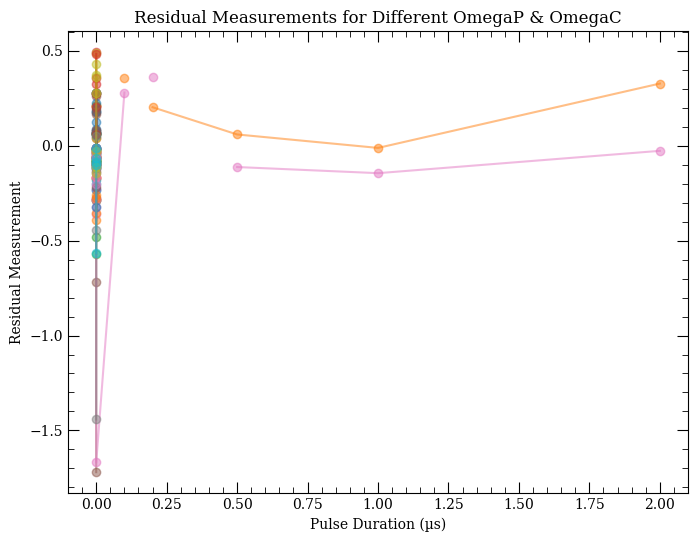

In [163]:
# Load the CSV file
csv_filename = "measurement_residual_data.csv"
df = pd.read_csv(csv_filename)

# Extract Pulse Duration (X-axis)
x_values = df.iloc[:, 0]  # First column is Pulse Duration (µs)

# Remove the first column (Pulse Duration) for Y values
df = df.set_index(df.columns[0])

# Create the plot
plt.figure(figsize=(8, 6))

# Iterate through each column (Each OmegaP, OmegaC combination)
for col in df.columns:
    y_values = df[col]

    # Plot with transparency (alpha)
    plt.plot(x_values, y_values, linestyle="-", marker="o", alpha=0.5, label=col)  # Transparent line & dots

# Log scale for better visualization (Optional)
#plt.xscale("log")

# Labels & Title
plt.xlabel("Pulse Duration (µs)")
plt.ylabel("Residual Measurement")
plt.title("Residual Measurements for Different OmegaP & OmegaC")
#plt.legend(fontsize=7, loc="best", frameon=False)  # Smaller legend

# Save & Show Plot
plt.savefig("residual_plot.png", dpi=300, bbox_inches='tight')
plt.show()

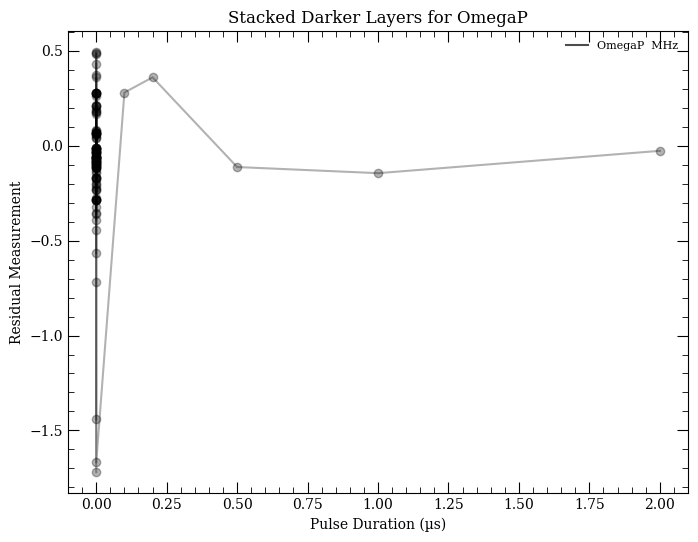

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the CSV file
csv_filename = "measurement_residual_data.csv"
df = pd.read_csv(csv_filename)

# Extract Pulse Duration (X-axis)
x_values = df.iloc[:, 0]  # First column is Pulse Duration (µs)

# Set Pulse Duration as the index and drop the first column
df = df.set_index(df.columns[0])

# Extract unique OmegaP values from column names
omegaP_values = sorted(set(col.split("_")[1] for col in df.columns))  # Unique OmegaP values

# Generate a range of gray shades (lighter → darker)
color_shades = np.linspace(0.3, 0.9, len(omegaP_values))  # Light gray (0.3) to dark gray (0.9)
omegaP_color_map = {omegaP: color for omegaP, color in zip(omegaP_values, color_shades)}

# Create the plot
plt.figure(figsize=(8, 6))

# Track which OmegaP labels have been added (to avoid duplicate legend entries)
added_labels = set()

# Iterate through each column (Each OmegaP, OmegaC combination)
for col in df.columns:
    omegaP = col.split("_")[1]  # Extract OmegaP from column name
    y_values = df[col]

    # Plot with progressively darker shades of gray
    plt.plot(x_values, y_values, linestyle="-", marker="o", alpha=omegaP_color_map[omegaP], color="black")

    # Add legend entry only once per OmegaP
    if omegaP not in added_labels:
        plt.plot([], [], linestyle="-", color=str(omegaP_color_map[omegaP]), label=f"OmegaP {omegaP} MHz")  # Dummy entry for legend
        added_labels.add(omegaP)

# Log scale for better visualization (Optional)
#plt.xscale("log")

# Labels & Title
plt.xlabel("Pulse Duration (µs)")
plt.ylabel("Residual Measurement")
plt.title("Stacked Darker Layers for OmegaP")

# Show only OmegaP labels in the legend
plt.legend(fontsize=8, loc="best", frameon=False)

# Save & Show Plot
plt.savefig("residual_stacked_gray_plot.png", dpi=300, bbox_inches='tight')
plt.show()


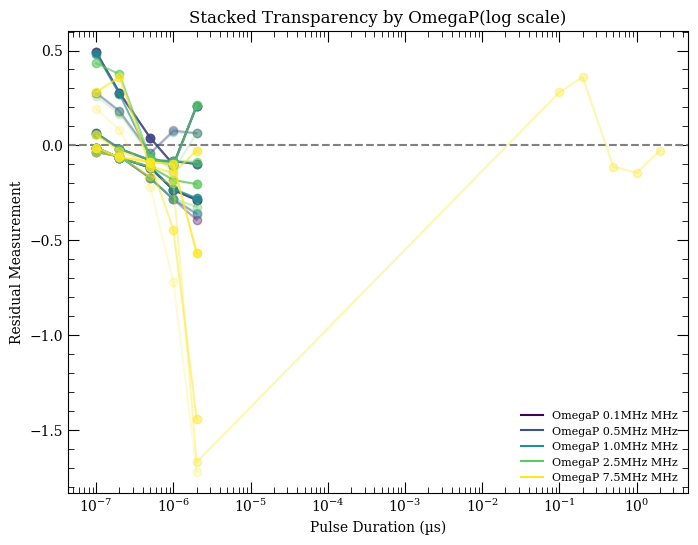

In [49]:
# Load the CSV file
csv_filename = "measurement_residual_data.csv"
df = pd.read_csv(csv_filename)

# Extract Pulse Duration (X-axis)
x_values = df.iloc[:, 0]  # First column is Pulse Duration (µs)

# Set Pulse Duration as the index and drop the first column
df = df.set_index(df.columns[0])

# Extract **unique** OmegaP values from column names
omegaP_values = sorted(set(col.split("__")[1] for col in df.columns))  # Unique OmegaP values

# Define a **distinct color** for each unique OmegaP
colors = plt.cm.viridis(np.linspace(0, 1, len(omegaP_values)))  # Using Viridis colormap for clear separation
omegaP_color_map = {omegaP: color for omegaP, color in zip(omegaP_values, colors)}

# Create the plot
plt.figure(figsize=(8, 6)) 
plt.axhline(y=0.0, color="gray", linestyle="--", linewidth=1.5)

# Track OmegaP plot occurrences (for increasing transparency)
plot_counts = {omegaP: 0 for omegaP in omegaP_values}

# Iterate through each column (Each OmegaP, OmegaC combination)
for col in df.columns:
    omegaP = col.split("__")[1]  # Extract OmegaP from column name (double underscore for safety)
    y_values = df[col]

    # **Increase transparency for stacking effect**
    alpha_value = 0.2 + (plot_counts[omegaP] * 0.15)  # Each new plot becomes **darker**
    alpha_value = min(alpha_value, 1.0)  # Ensure max alpha does not exceed 1

    # **Plot all curves of the same OmegaP with the same color**
    plt.plot(x_values, y_values, linestyle="-", marker="o", alpha=alpha_value, color=omegaP_color_map[omegaP])

    # Increment counter to **darken stacking effect**
    plot_counts[omegaP] += 1

# **Fix Legend: Show Each OmegaP with Unique Color**
for omegaP, color in omegaP_color_map.items():
    plt.plot([], [], linestyle="-", color=color, label=f"OmegaP {omegaP} MHz")  # Dummy entry for legend

# **Log scale for better visualization (Optional)**
plt.xscale("log")

# Labels & Title
plt.xlabel("Pulse Duration (µs)")
plt.ylabel("Residual Measurement")
plt.title("Stacked Transparency by OmegaP(log scale)")

# Show only **unique OmegaP values** in legend
plt.legend(fontsize=8, loc="best", frameon=False)

# Save & Show Plot
plt.savefig("residual_stacked_color_plot.png", dpi=300, bbox_inches='tight')
plt.show()

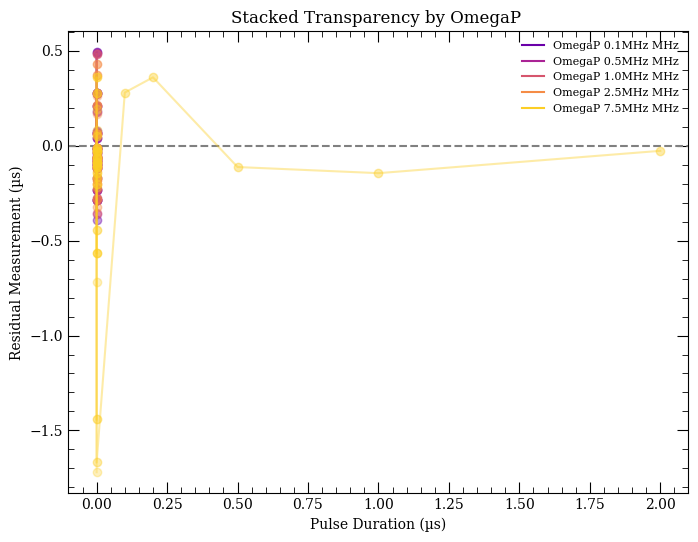

In [50]:
csv_filename = "measurement_residual_data.csv"
df = pd.read_csv(csv_filename)

# Extract Pulse Duration (X-axis)
x_values = df.iloc[:, 0]  # First column is Pulse Duration (µs)

# Set Pulse Duration as the index and drop the first column
df = df.set_index(df.columns[0])

# Extract unique OmegaP values from column names
omegaP_values = sorted(set(col.split("__")[1] for col in df.columns))  # Unique OmegaP values

# **Use a better colormap with higher contrast**
colors = plt.cm.plasma(np.linspace(0.2, 0.9, len(omegaP_values)))  # Plasma avoids bright yellows

# Map OmegaP values to these adjusted colors
omegaP_color_map = {omegaP: color for omegaP, color in zip(omegaP_values, colors)}

# Create the plot
plt.figure(figsize=(8, 6)) 
plt.axhline(y=0.0, color="gray", linestyle="--", linewidth=1.5)

# Track OmegaP plot occurrences (for increasing transparency)
plot_counts = {omegaP: 0 for omegaP in omegaP_values}

# Iterate through each column (Each OmegaP, OmegaC combination)
for col in df.columns:
    omegaP = col.split("__")[1]  # Extract OmegaP from column name
    y_values = df[col]

    # **Increase transparency for stacking effect**
    alpha_value = 0.3 + (plot_counts[omegaP] * 0.1)  # Gradually darken
    alpha_value = min(alpha_value, 1.0)  # Cap at full opacity

    # **Plot each OmegaP with the same adjusted color**
    plt.plot(x_values, y_values, linestyle="-", marker="o", alpha=alpha_value, color=omegaP_color_map[omegaP])

    # Increment counter to **darken stacking effect**
    plot_counts[omegaP] += 1

# **Fix Legend: Show Each OmegaP with Unique Color**
for omegaP, color in omegaP_color_map.items():
    plt.plot([], [], linestyle="-", color=color, label=f"OmegaP {omegaP} MHz")  # Dummy entry for legend

# Log scale for better visualization (Optional)
#plt.xscale("log")

# Labels & Title
plt.xlabel("Pulse Duration (µs)")
plt.ylabel("Residual Measurement (µs)")
plt.title("Stacked Transparency by OmegaP ")

# Show only **unique OmegaP values** in legend
plt.legend(fontsize=8, loc="best", frameon=False)

# Save & Show Plot
plt.savefig("residual_stacked_better_colors.png", dpi=300, bbox_inches='tight')
plt.show()

In [51]:
er=

SyntaxError: invalid syntax (3352773177.py, line 1)

# line width checking 

In [ ]:
# create list of delta_p values
deltalist = np.linspace(-200,200,401)
# empty list to save results
chi = [] # susceptibility

In [ ]:
#define Rabies frequency 
#E=1E3
deltaC = 0 # coupling field detuning  
omegaC_list = [10,20,50,100,200]
deltaRF = 0 
#For omegaP and OmagaC is 1 MHz
omegaP = 1E6 # Rabi freq. for probe
omegaC = 100E6 # Rabi freq. for control  
#omegaP_list = [(10*i)*1e6 for i in range(7)] 
deltaP0 = 1E6

In [ ]:
deltaP =0  
deltaC = 0 
omega = 0 
omegaP = 40E6 # Rabi freq. for probe
omegaC = 10E6 # Rabi freq. for control 
res=[]
for omegaP in deltalist:
    H = 1/2*Qobj([[0,omegaP,0,0],[omegaP,-2*(deltaP)*10**6,omegaC,0]
            ,[0,omegaC,-2*(deltaP+deltaC)*10**6,0],
                       [0,0,0,-2*(deltaP+deltaC+deltaRF)*10**6]])
    rho_ss = steadystate(H,collapse)  
    res.append(expect(sig_12.dag(),rho_ss)) 
Efield = E_from_Rabi(omegaP,abs(dipmat12))   
chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res]  
transmittance = [transmission(L,np.imag(i),lambda12) for i in chi] 

In [ ]:
omegaP = 0.5E6 
omegaC_list = np.array([5,10,25,50,100])*1e6 
omegaP_list = np.array([0.1,0.5,1,2,8])*1e6
chi_list=[] 
deltaP =0  
deltaC = 0 
omega = 0 
for omegaP in tqdm(omegaP_list) : 
    res=[]
    for deltaC in deltalist:
        H = 1/2*Qobj([[0,omegaP,0,0],[omegaP,-2*(deltaP)*10**6,omegaC,0]
               ,[0,omegaC,-2*(deltaP+deltaC)*10**6,omega],
                       [0,0,omega,-2*(deltaP+deltaC+deltaRF)*10**6]])
        rho_ss = steadystate(H,collapse)  
        res.append(expect(sig_12.dag(),rho_ss)) 
    Efield = E_from_Rabi(omegaP,abs(dipmat12))   
    print(Efield)
    chi = [susceptibility(N_0,np.abs(dipmat12),Efield,rho) for rho in res]  
    transmittance = [transmission(L,np.imag(i),lambda12) for i in chi] 
    print(transmittance)
    refraction = np.real(chi)
    absorption = 2*pi*np.imag(chi)/lambda12 
    chi_list.append(chi)

 20%|██        | 1/5 [00:00<00:02,  1.44it/s]

0.5096388822225328
[np.float64(2.5738226480040274e-29), np.float64(2.574048491143166e-29), np.float64(2.574277773083526e-29), np.float64(2.5745105640379386e-29), np.float64(2.5747469360215555e-29), np.float64(2.5749869629075333e-29), np.float64(2.575230720484854e-29), np.float64(2.5754782865186893e-29), np.float64(2.5757297408121856e-29), np.float64(2.575985165271055e-29), np.float64(2.5762446439705084e-29), np.float64(2.5765082632246163e-29), np.float64(2.5767761116582695e-29), np.float64(2.5770482802815814e-29), np.float64(2.5773248625680813e-29), np.float64(2.577605954534482e-29), np.float64(2.577891654824584e-29), np.float64(2.57818206479616e-29), np.float64(2.5784772886106074e-29), np.float64(2.57877743332746e-29), np.float64(2.5790826090007054e-29), np.float64(2.579392928780861e-29), np.float64(2.5797085090196415e-29), np.float64(2.580029469379389e-29), np.float64(2.580355932947172e-29), np.float64(2.580688026352679e-29), np.float64(2.58102587989184e-29), np.float64(2.58136962765

 40%|████      | 2/5 [00:01<00:02,  1.44it/s]

2.548194411112664
[np.float64(2.6190663372921254e-29), np.float64(2.619296772989686e-29), np.float64(2.619530716296201e-29), np.float64(2.619768238803911e-29), np.float64(2.620009413941337e-29), np.float64(2.620254317031249e-29), np.float64(2.6205030253492535e-29), np.float64(2.620755618184449e-29), np.float64(2.621012176903565e-29), np.float64(2.621272785016256e-29), np.float64(2.621537528242961e-29), np.float64(2.6218064945861225e-29), np.float64(2.6220797744032775e-29), np.float64(2.622357460482742e-29), np.float64(2.622639648123374e-29), np.float64(2.622926435215796e-29), np.float64(2.623217922328083e-29), np.float64(2.623514212793705e-29), np.float64(2.6238154128038846e-29), np.float64(2.624121631502485e-29), np.float64(2.6244329810853745e-29), np.float64(2.6247495769037545e-29), np.float64(2.625071537570684e-29), np.float64(2.625398985073161e-29), np.float64(2.625732044887757e-29), np.float64(2.626070846100907e-29), np.float64(2.626415521534868e-29), np.float64(2.626766207877694e

 60%|██████    | 3/5 [00:02<00:01,  1.45it/s]

5.096388822225328
[np.float64(2.7654787368379306e-29), np.float64(2.76572410421171e-29), np.float64(2.7659732028015277e-29), np.float64(2.7662261086781846e-29), np.float64(2.766482899862459e-29), np.float64(2.766743656384501e-29), np.float64(2.76700846034729e-29), np.float64(2.7672773959905905e-29), np.float64(2.767550549758674e-29), np.float64(2.767828010369524e-29), np.float64(2.768109868887428e-29), np.float64(2.768396218797544e-29), np.float64(2.768687156083625e-29), np.float64(2.768982779308913e-29), np.float64(2.769283189699736e-29), np.float64(2.769588491231818e-29), np.float64(2.7698987907216684e-29), np.float64(2.7702141979188946e-29), np.float64(2.770534825604361e-29), np.float64(2.7708607896910173e-29), np.float64(2.771192209329109e-29), np.float64(2.7715292070148987e-29), np.float64(2.7718719087046623e-29), np.float64(2.772220443932382e-29), np.float64(2.7725749459328957e-29), np.float64(2.772935551768852e-29), np.float64(2.773302402464532e-29), np.float64(2.773675643143157

 80%|████████  | 4/5 [00:02<00:00,  1.45it/s]

10.192777644450656
[np.float64(3.434601861179037e-29), np.float64(3.434916692596298e-29), np.float64(3.4352362936208784e-29), np.float64(3.4355607610801374e-29), np.float64(3.4358901942718294e-29), np.float64(3.436224695039955e-29), np.float64(3.436564367853465e-29), np.float64(3.436909319888086e-29), np.float64(3.437259661111056e-29), np.float64(3.437615504368702e-29), np.float64(3.4379769654772964e-29), np.float64(3.438344163317886e-29), np.float64(3.438717219933439e-29), np.float64(3.4390962606312615e-29), np.float64(3.4394814140878914e-29), np.float64(3.439872812458453e-29), np.float64(3.4402705914903705e-29), np.float64(3.4406748906409285e-29), np.float64(3.4410858532005374e-29), np.float64(3.441503626418987e-29), np.float64(3.44192836163788e-29), np.float64(3.4423602144283776e-29), np.float64(3.4427993447332976e-29), np.float64(3.4432459170160747e-29), np.float64(3.443700100414697e-29), np.float64(3.444162068902444e-29), np.float64(3.444632001454519e-29), np.float64(3.44511008222

100%|██████████| 5/5 [00:03<00:00,  1.45it/s]

40.771110577802624
[np.float64(1.9761067014291475e-27), np.float64(1.9763888858168246e-27), np.float64(1.9766751774147454e-27), np.float64(1.97696565569177e-27), np.float64(1.9772604020359663e-27), np.float64(1.977559499810705e-27), np.float64(1.977863034412077e-27), np.float64(1.9781710933282437e-27), np.float64(1.9784837662012124e-27), np.float64(1.9788011448904596e-27), np.float64(1.9791233235387674e-27), np.float64(1.9794503986404938e-27), np.float64(1.9797824691120857e-27), np.float64(1.9801196363651972e-27), np.float64(1.9804620043822165e-27), np.float64(1.980809679794671e-27), np.float64(1.9811627719643863e-27), np.float64(1.981521393067351e-27), np.float64(1.981885658180982e-27), np.float64(1.9822556853739654e-27), np.float64(1.9826315958004424e-27), np.float64(1.983013513796112e-27), np.float64(1.983401566979398e-27), np.float64(1.9837958863553582e-27), np.float64(1.984196606423831e-27), np.float64(1.984603865291719e-27), np.float64(1.9850178047889956e-27), np.float64(1.985438

In [ ]:
font1 = {'family':'serif','color':'black','size':20}
font2 = {'family':'serif','color':'black','size':15}
for i in range(len(chi_list)):  
    #chi_list[0] = np.zeros(len(chi_list[0]))
    plt.plot(deltalist,-np.imag(chi_list[i]),label="$\Omega_{P}$-"+str(omegaP_list[i]/1E6)+" MHz") 
    #plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    plt.xlabel("$\Delta_C$"+" MHz", fontdict = font2)     
    plt.ylabel("-Im[$\chi$]", fontdict = font2)
plt.suptitle('32S EIT -' + r"transmittance" + "$ - \Delta_C$ (MHz)"+"$ - \Omega_P$ - 0.5 (MHz)", fontdict = font2) 
#    plt.yticks([])  
#plt.xlim(-5,5)  
#plt.xlim(-10,10)
# check imaginary path of chi  
plt.legend()
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\O'
<>:5: SyntaxWarning: invalid escape sequence '\O'
<>:7: SyntaxWarning: invalid escape sequence '\D'
<>:8: SyntaxWarning: invalid escape sequence '\c'
<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\O'
C:\Users\beam_\AppData\Local\Temp\ipykernel_6284\1793476196.py:5: SyntaxWarning: invalid escape sequence '\O'
  plt.plot(deltalist,-np.imag(chi_list[i]),label="$\Omega_{P}$-"+str(omegaP_list[i]/1E6)+" MHz")
C:\Users\beam_\AppData\Local\Temp\ipykernel_6284\1793476196.py:7: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("$\Delta_C$"+" MHz", fontdict = font2)
C:\Users\beam_\AppData\Local\Temp\ipykernel_6284\1793476196.py:8: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel("-Im[$\c

TypeError: Got both 'size' and 'fontsize', which are aliases of one another